# Neapolitan Large Pizza (NLP)
Group assignment for the course "Natural Language Processing" at Politecnico di Milano, A.Y. 2023/2024

**Name of the group:** Neapolitan Large Pizza (NLP)

**Members of the group:**
*  Marco Galliani
*  Raffaele Scorza
*  Claudio Strino
*  Lorenzo Tanzi



# Environment

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

path = 'progetto nlp'

os.chdir(f"/content/drive/MyDrive/{path}")
os.getcwd()

Mounted at /content/drive


'/content/drive/.shortcut-targets-by-id/1UVjHQ5CyZQC-knkRUABL-FobD5CYM94q/progetto nlp'

In [ ]:
!pip install torch torchvision torchaudio
!pip install -q transformers datasets
!pip install accelerate -U
!pip install evaluate


In [ ]:
#General utilities
import numpy as np
import pandas as pd
import re

#sklearn utilities
from sklearn.preprocessing import MinMaxScaler, Normalizer, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.base import BaseEstimator, TransformerMixin

#classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

#plotting
import seaborn as sns
import matplotlib.pyplot as plt

#Pytorch framework
import torch
from torch import nn ,cuda
from torch.utils.data import DataLoader,Dataset,RandomSampler, SequentialSampler

#Huggingface framework
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from transformers import LongformerTokenizerFast, LongformerForSequenceClassification, LongformerConfig

from transformers import TrainingArguments, Trainer
from transformers import EvalPrediction

from datasets import Dataset, DatasetDict

In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type != 'cuda':
    raise SystemError('GPU device not found')

# 0) Data exploration

**Cornell Movie-Dialog Corpus**

This corpus contains a metadata-rich collection of fictional conversations extracted from raw movie scripts:

- 220,579 conversational exchanges between 10,292 pairs of movie characters
- involves 9,035 characters from 617 movies
- in total 304,713 utterances

The files contained are:
- movie_titles_metadata.txt
- movie_characters_metadata.txt
- movie_lines.txt
- movie_conversations.txt

In all files the field separator is " +++$+++ "

We downloaded the dataset from the official account of the Cornell University on Kaggle, [here](https://www.kaggle.com/datasets/Cornell-University/movie-dialog-corpus).




In [ ]:
dataset_path = "cornell movie-dialogs corpus"

In [ ]:
conversations = pd.read_csv(
    f"{dataset_path}/movie_conversations.tsv",
    sep='\t',
    encoding='ISO-8859-2',
    names = ['charID_1', 'charID_2', 'movieID', 'conversation']
)
conversations.dropna(inplace=True)

characters = pd.read_csv(
    f"{dataset_path}/movie_characters_metadata.tsv",
    sep='\t',
    header = None,
    on_bad_lines= "skip",
    names = ['charID','charName','movieID','movieName','gender','score'],
    index_col=['charID']
)
characters.dropna(inplace=True)

lines = pd.read_csv(
    f"{dataset_path}/movie_lines.tsv",
    encoding='utf-8-sig',
    sep='\t',
    on_bad_lines="skip",
    header = None,
    names = ['lineID', 'charID', 'movieID', 'charName', 'text'],
    index_col=['lineID']
)
lines.dropna(inplace=True)

titles = pd.read_csv(
    f"{dataset_path}/movie_titles_metadata.tsv",
    sep='\t',
    header=None,
    on_bad_lines="skip",
    names=['movieID', 'title', 'year', 'ratingIMDB', 'votes', 'genresIMDB'],
    index_col=['movieID']
)
titles.dropna(inplace=True)

## Characters dataset

The characters dataset contains:
- charName: names of the characters
- movieName: name of the movie to which the character belong
- gender: gender of the character
- score: score of the character (Relevance of the character in the movie)
- movieID: to perform the join with the lines dataset

In [ ]:
characters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9015 entries, u0 to u9034
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   charName   9015 non-null   object
 1   movieID    9015 non-null   object
 2   movieName  9015 non-null   object
 3   gender     9015 non-null   object
 4   score      9015 non-null   object
dtypes: object(5)
memory usage: 422.6+ KB


Let's inspect the distributions of the variabels

<BarContainer object of 2 artists>

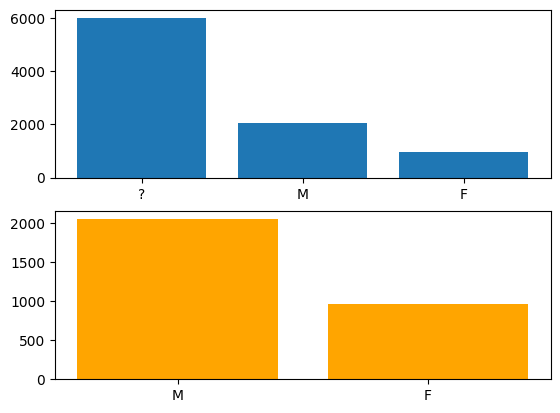

In [ ]:
#gender
characters.gender = characters.gender.str.upper()

fig, axs = plt.subplots(2, 1)  # 2 rows, 1 column
axs[0].bar(characters.gender.value_counts().keys(),characters.gender.value_counts())

# removing "?"
axs[1].bar(characters[characters.gender != '?'].gender.value_counts().keys(),
           characters[characters.gender != '?'].gender.value_counts(),
           color='orange')

Score variable

<BarContainer object of 10 artists>

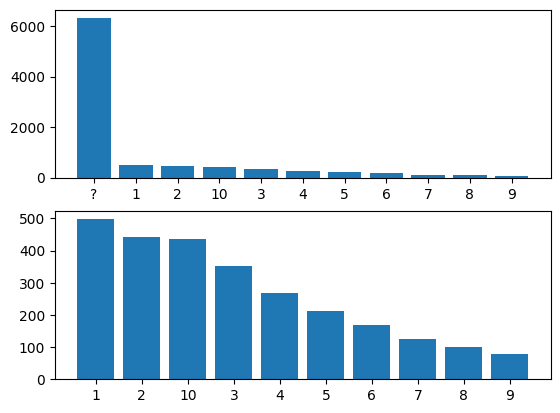

In [ ]:
#score
characters.score = characters.score.apply(
    lambda x: '10' if not x in ['1','2','3','4','5','6','7','8','9', '?'] else x
    )

fig, axs = plt.subplots(2, 1)  # 2 rows, 1 column

axs[0].bar(characters.score.value_counts().keys(), characters.score.value_counts())

# removing "?"
axs[1].bar(characters[characters.score != '?'].score.value_counts().keys(), characters[characters.score != '?'].score.value_counts())

Dropping the NAs

In [ ]:
characters = characters[characters.score != '?']
characters = characters[characters.gender != '?']

## Movies dataset

The titles dataset contains:
- title: title of the movie
- year: year of release
- ratingIMDB: assigned to the movie
- votes: number of reviews on IMDB
- genresIMDB: genre labels assigned by IMDB to the movie

In [ ]:
titles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 616 entries, m0 to m616
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       616 non-null    object 
 1   year        616 non-null    object 
 2   ratingIMDB  616 non-null    float64
 3   votes       616 non-null    float64
 4   genresIMDB  616 non-null    object 
dtypes: float64(2), object(3)
memory usage: 28.9+ KB


Rating IMDB and number of reviews for each movie

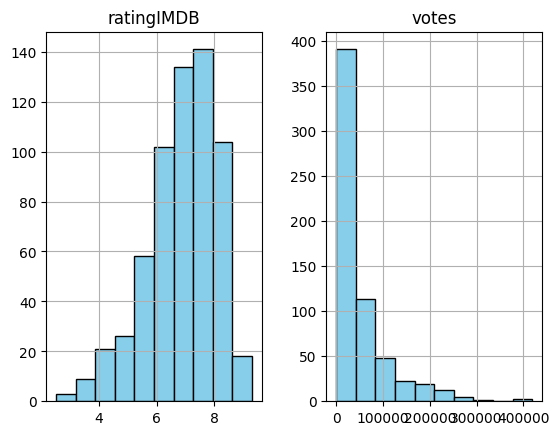

In [ ]:
# rating IMDB & votes
titles.hist(color='skyblue', edgecolor='black')
plt.show()

Genres count

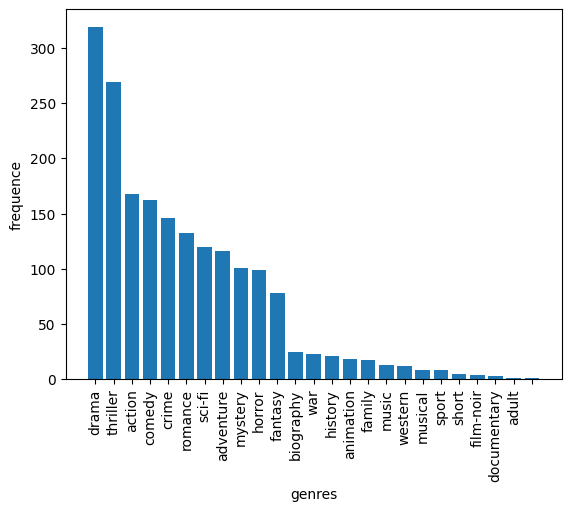

In [ ]:
genres_counter = titles['genresIMDB'].apply(lambda x: x[2:-2].split("' '")).explode().value_counts()

plt.bar(genres_counter.keys(), genres_counter)
plt.xticks(rotation='vertical')

# Adding labels and title
plt.xlabel('genres')
plt.ylabel('frequence')

# Displaying the plot
plt.show()

## Conversation dataset

The conversations dataset contains a list of line IDs to construct the dialogues together with the lines dataset:
- charID_1: to perform the join with the characters dataset
- charID_2: to perform the join with the characters dataset
- movieID: to perform the join with the titles dataset
- conversations: list of line IDs to contruct the dialogues

In [ ]:
conversations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83097 entries, 0 to 83096
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   charID_1      83097 non-null  object
 1   charID_2      83097 non-null  object
 2   movieID       83097 non-null  object
 3   conversation  83097 non-null  object
dtypes: object(4)
memory usage: 2.5+ MB


In [ ]:
conversations.head()

,charID_1,charID_2,movieID,conversation
0,u0,u2,m0,['L194' 'L195' 'L196' 'L197']
1,u0,u2,m0,['L198' 'L199']
2,u0,u2,m0,['L200' 'L201' 'L202' 'L203']
3,u0,u2,m0,['L204' 'L205' 'L206']
4,u0,u2,m0,['L207' 'L208']


Here we display the distribution of the length of the dialogues

In [ ]:
# Sort dialogues by length in descending order
conversations['conversation'] = conversations['conversation'].map(lambda x: re.findall(r"\w+", x))


conversations['length'] = conversations['conversation'].apply(lambda x: len(x))

conversations.sort_values(by=['length'], ascending=False)

,charID_1,charID_2,movieID,conversation,length
42477,u4522,u4525,m299,"[L135360, L135361, L135362, L135363, L135364, ...",89
73134,u7932,u7936,m537,"[L553902, L553903, L553904, L553905, L553906, ...",59
70355,u7663,u7666,m518,"[L513247, L513248, L513249, L513250, L513251, ...",56
45571,u4857,u4866,m324,"[L167261, L167262, L167263, L167264, L167265, ...",55
11348,u1240,u1243,m82,"[L267558, L267559, L267560, L267561, L267562, ...",54
...,...,...,...,...,...
20661,u2256,u2265,m145,"[L412100, L412101]",2
55457,u6020,u6022,m400,"[L308227, L308228]",2
11491,u1244,u1248,m82,"[L268306, L268307]",2
55459,u6021,u6024,m400,"[L308517, L308518]",2


count    83097.000000
mean         3.666955
std          2.891798
min          2.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         89.000000
Name: length, dtype: float64


<Axes: xlabel='length'>

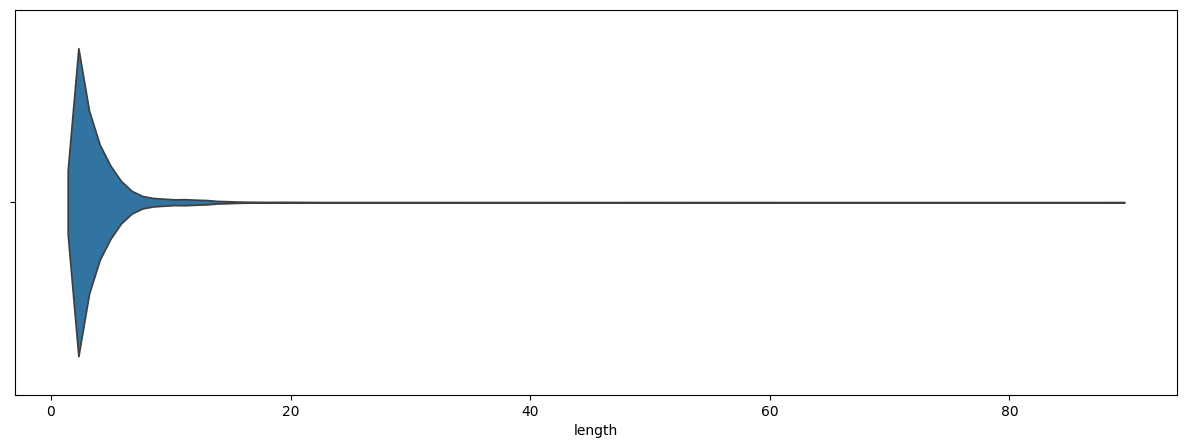

In [ ]:
print(conversations.length.describe())
fig, ax = plt.subplots(figsize=(15,5))
sns.violinplot(ax=ax, x=conversations.length, inner=None)

Here we try to verify the Heap's law over the evolution of the vocabulary length

> **Heap’s law**: Vocabulary grows with approximately the square root of document length

Is it true for a random film's script?





In [ ]:
# Clean and tokenize the text.
def preprocess(text):

    text = re.sub(r'[^A-Za-z\s]', '', text)  # Removes special characters and numbers.
    text = text.lower()  # Convert to lowercase
    words = text.split()  # Tokenize text in words
    return words


In [ ]:
#Compute the cumulative vocabulary
def calculate_vocabulary(words):
    vocab_set = set()
    vocab_growth = []
    for word in words:
        vocab_set.add(word)
        vocab_growth.append(len(vocab_set))
    return vocab_growth


In [ ]:
#Generate the vocabulary graph
def plot_vocabulary_growth(vocab_growth):
    x = np.arange(1, len(vocab_growth) + 1)

    plt.figure(figsize=(10, 6))

    plt.plot(x, vocab_growth, label='Vocabulary Growth')
    plt.plot(x, 10*np.power(x,0.5), label='10x^{0.5}')
    plt.plot(x, 10*np.power(x,0.6), label='10x^{0.6}')

    plt.xlabel('Number of Words in the Script')
    plt.ylabel('Number of Distinct Words')

    plt.title('Vocabulary Growth in the Script of a Movie')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.gca().set_aspect('equal', adjustable='box')  #  1:1

    plt.show()

In [ ]:
#Analyzes the growth of vocabulary in a movie script.
def analyze_script_vocabulary(dataset_path, movie_title):

    # Find the movieID corresponding to the movie title
    movie_id = titles[titles['title'] == movie_title].index.values[0]

    # Filter dialogue lines for the specific movie
    script_df = lines[lines['movieID'] == movie_id]

    # Concatenate all text from dialogue lines
    full_text = ' '.join(script_df['text'].dropna())

    # Pass the concatenated string to the preprocess function
    words = preprocess(full_text)

    # Calculate the cumulative vocabulary
    vocab_growth = calculate_vocabulary(words)

    # Generate the plot of vocabulary growth
    plot_vocabulary_growth(vocab_growth)


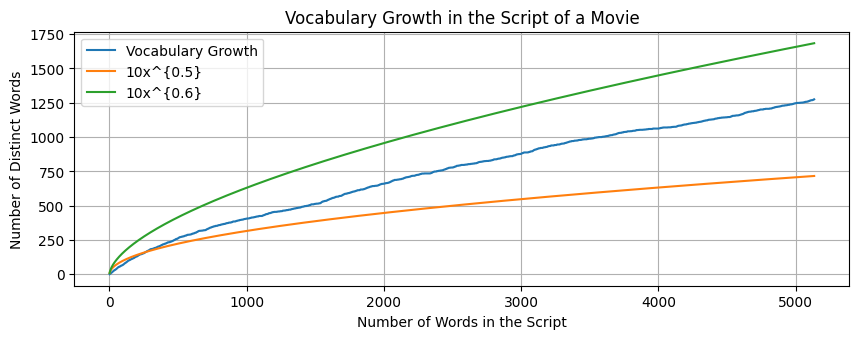

In [ ]:
analyze_script_vocabulary(dataset_path, '10 things i hate about you')

## Lines dataset

The lines dataset contains:
- charID: to perform the join with the characters dataset
- movieID: to perform the join with the titles dataset
- text: the line said by the character charID in the movie movieID

In [ ]:
lines.info()

<class 'pandas.core.frame.DataFrame'>
Index: 288620 entries, L1045 to L666256
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   charID    288620 non-null  object
 1   movieID   288620 non-null  object
 2   charName  288620 non-null  object
 3   text      288620 non-null  object
dtypes: object(4)
memory usage: 11.0+ MB


In [ ]:
lines.head()

,charID,movieID,charName,text
lineID,,,,
L1045,u0,m0,BIANCA,They do not!
L1044,u2,m0,CAMERON,They do to!
L985,u0,m0,BIANCA,I hope so.
L984,u2,m0,CAMERON,She okay?
L925,u0,m0,BIANCA,Let's go.


# 1) Sentiment analysis

In this section we perform a sentiment analysis on the dialogues in the dataset, using a pretrained model (in this case: 'distilbert-base-uncased-finetuned-sst-2-english', i.e. the default one in the sentiment analysis pipeline API from huggingface).

Later on we're gonna use the positive and negative probabilities outputted by the model as features in our text classifier.

## Data preprocessing

In [ ]:
#conversations['conversation'] = conversations['conversation'].apply(lambda x: x[2:-2].split("' '"))

conversations_exploded = conversations.explode('conversation').reset_index()
conversations_exploded.rename(
    columns={'conversation': 'lineID',
             'index': 'convID'},
    inplace=True)

# Merge conversations_exploded with lines based on line IDs
conversations_lines = pd.merge(
    conversations_exploded, lines.reset_index(),
    on=['lineID', 'movieID'])

# Construct the lines of a dialogue as "{charName}: {line}""
#conversations_lines.text = (conversations_lines.charName + ': ' + conversations_lines.text).astype(str)
conversations_lines.head()

,convID,charID_1,charID_2,movieID,lineID,length,charID,charName,text
0,0,u0,u2,m0,L194,4,u0,BIANCA,Can we make this quick? Roxanne Korrine and A...
1,0,u0,u2,m0,L195,4,u2,CAMERON,Well I thought we'd start with pronunciation i...
2,0,u0,u2,m0,L196,4,u0,BIANCA,Not the hacking and gagging and spitting part....
3,0,u0,u2,m0,L197,4,u2,CAMERON,Okay... then how 'bout we try out some French ...
4,1,u0,u2,m0,L198,2,u0,BIANCA,You're asking me out. That's so cute. What's ...


Building the dialogues dataset

This join utility is actually quite important as we don't want our model to learn the association between names of the characters and genre of the movie. We're gonna explain this further in the text classification section

In [ ]:
def alternate_join(strings):
    result = []
    prefixes = ["A: ", "B: "]
    for i, s in enumerate(strings):
        result.append(prefixes[i % 2] + s)
    return '\n'.join(result)

Each dialogue is formatted to have "A:" and "B:" as character identifiers

In [ ]:
# Grouping by index, charID_1, charID_2, and movieID, and aggregating text
dialogues = conversations_lines.groupby(['convID','charID_1','charID_2','movieID']).agg(
    dialogue = ('text', lambda x: alternate_join(x))).reset_index()

dialogues = dialogues.set_index('convID')

# merge film metadata information
dialogues = pd.merge(
    dialogues, titles,
    on = 'movieID'
)

dialogues.drop(columns=['charID_1', 'charID_2'], inplace=True)
dialogues.head()

,movieID,dialogue,title,year,ratingIMDB,votes,genresIMDB
0,m0,A: Can we make this quick? Roxanne Korrine an...,10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']
1,m0,A: You're asking me out. That's so cute. What...,10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']
2,m0,A: No no it's my fault -- we didn't have a pro...,10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']
3,m0,A: Why?\nB: Unsolved mystery. She used to be ...,10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']
4,m0,A: Gosh if only we could find Kat a boyfriend....,10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']


## Inference using a pretrained model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
from transformers import TrainingArguments, Trainer

# Load the tokenizer and model
model_name = 'distilbert-base-uncased-finetuned-sst-2-english'

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.to(device)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

For an efficient inference we're gonna use the Trainer API, as using the huggingface pipeline API took a long time. Indeed, we're dealing with a very large dataset (we want to process almost 80000 dialogues)

In [ ]:
# Tokenize the dataset
def tokenize_function(example):
    return tokenizer(example["dialogue"], padding=False, truncation=True, max_length=512)

tokenized_dial_data = Dataset.from_pandas(df=dialogues).map(tokenize_function, batched=True)

# Convert tokenized inputs to PyTorch tensors
tokenized_dial_data.set_format(type='torch', columns=['input_ids', 'attention_mask'])

Map:   0%|          | 0/79791 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

A dummy training arguments, we don't want to perform any training, just inference on the whole dataset

In [ ]:
# Define training arguments (dummy arguments since we're only using Trainer for prediction)
training_args = TrainingArguments(
    output_dir='./results',
    per_device_eval_batch_size=8,  # Adjust batch size based on your hardware
    logging_dir='./logs',
    disable_tqdm=False,
)

# Create a Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    tokenizer=tokenizer,
    data_collator=data_collator
)

In [ ]:
predictions = trainer.predict(tokenized_dial_data)
logits = predictions.predictions
probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1)

In [ ]:
model.config.id2label

{0: 'NEGATIVE', 1: 'POSITIVE'}

In [ ]:
# adding the computed prob to the dialogue dataset
dialogues[['neg_prob','pos_prob']] = pd.DataFrame(probs.numpy())

## Build movie scripts dataset

Here we display the final structure of the dataset that we're gonna use in the text classification section.

We have grouped by movies to obtain a single long text string containing the script for each movie. While grouping we averaged the probabilities of negative and positive dialogues

In [ ]:
# Grouping by movie
movies = dialogues.groupby(
    ['movieID', 'title', 'year', 'ratingIMDB', 'votes', 'genresIMDB']
    ).agg(
        movieID_count = ('movieID','count'),
        script = ('dialogue', lambda x : '\n\n'.join(x)),
        neg_prob = ('neg_prob', 'mean'),
        pos_prob = ('pos_prob', 'mean')
        ).reset_index()

movies['genresIMDB'] = movies['genresIMDB'].apply(lambda x: x[2:-2].split("' '"))
movies.head()

,movieID,title,year,ratingIMDB,votes,genresIMDB,movieID_count,script,neg_prob,pos_prob
0,m0,10 things i hate about you,1999,6.9,62847.0,"[comedy, romance]",201,A: Can we make this quick? Roxanne Korrine an...,0.675871,0.324129
1,m1,1492: conquest of paradise,1992,6.2,10421.0,"[adventure, biography, drama, history]",93,A: I never seen heat like this! Not even in L...,0.581932,0.418068
2,m10,affliction,1997,6.9,7252.0,"[drama, mystery, thriller]",115,A: You got yourself a computer Alma.\nB: Been ...,0.777947,0.222053
3,m100,innerspace,1987,6.5,16854.0,"[action, adventure, comedy, crime, sci-fi]",300,A: I said something.\nB: I know you did!\n\nA:...,0.687200,0.312800
4,m101,the insider,1999,8.0,69660.0,"[biography, drama, thriller]",161,A: Hi honey.\nB: Hi Daddy.\nA: What's new?\nB:...,0.695061,0.304939


## Display some results

The positive mean probabilities are larger for the movies with the 'comedy' and 'romance' label

In [ ]:
movies[movies.pos_prob>0.60]

,movieID,title,year,ratingIMDB,votes,genresIMDB,movieID_count,script,neg_prob,pos_prob
183,m266,being there,1979,8.0,25085.0,"[drama, comedy]",180,A: The injection will ease the pain and swelli...,0.371377,0.628623
335,m406,the jazz singer,1927,6.8,3252.0,"[drama, music, romance]",1,A: Did you like that Mama?\nB: Yes.\nA: I'm gl...,0.004472,0.995528
470,m53,the elephant man,1980,8.4,59625.0,"[biography, drama, history]",105,A: Mr. Merrick sugar?\nB: Yes please two.\nA: ...,0.341837,0.658163
599,m93,human nature,2001,6.3,10017.0,"[comedy, drama]",85,A: And furthermore... Tell him Harold.\nB: Uh....,0.337756,0.662244


The negative mean probabilities are larger for the movies labelled as 'crime','thriller'

In [ ]:
movies[movies.neg_prob>0.85]

,movieID,title,year,ratingIMDB,votes,genresIMDB,movieID_count,script,neg_prob,pos_prob
191,m273,book of shadows: blair witch 2,2000,4.1,16285.0,"[crime, horror, mystery, thriller]",163,A: --and if she ever did--\nB: --which she may...,0.864667,0.135333
257,m333,enemy of the state,1998,7.2,67504.0,"[action, drama, thriller]",145,A: Brill?\n\nA: It started with the informatio...,0.854480,0.145520
280,m357,the french connection,1971,7.9,34062.0,"[action, crime, thriller]",43,A: What about you Doyle? Who's the best fight...,0.899808,0.100192
336,m407,jennifer eight,1992,6.2,6224.0,"[thriller, mystery]",124,A: As I said Sergeant you nearly ran into <u>m...,0.885155,0.114844
389,m456,the negotiator,1998,7.2,46983.0,"[action, crime, drama, mystery, thriller]",9,A: I fucking hate Raoul. Shut the fuck up ass...,0.858225,0.141775
538,m591,unforgiven,1992,8.3,101270.0,"[drama, western]",132,A: She's gonna live. She didn't steal nothin'...,0.889806,0.110194
551,m602,what women want,2000,6.3,55269.0,"[comedy, fantasy, romance]",1,A: :What you're doing Darcy? Since when?\nB: :...,0.984400,0.015600


# 2) Text retrieval

## Creating Script only Dataset

To do this task we created a new dataset with the relevant information to text retrieval from movie scripts, such as script and movie title (used as doc reference)

In [ ]:
conversations_exploded = conversations.explode('conversation').reset_index()
conversations_exploded.rename(
    columns={'conversation': 'lineID',
             'index': 'convID'},
    inplace=True)

# Merge conversations_exploded with lines based on line IDs
conversations_lines = pd.merge(
    conversations_exploded, lines.reset_index(),
    on=['lineID', 'movieID'])

# Construct the lines of a dialogue as "{charName}: {line}""
conversations_lines.text = (conversations_lines.charName + ': ' + conversations_lines.text).astype(str)

# Grouping by index, charID_1, charID_2, and movieID, and aggregating text
dialogues = conversations_lines.groupby(['convID','charID_1','charID_2','movieID'])['text'].agg('\n'.join).reset_index()
dialogues = dialogues.set_index('convID')

dialogues.drop(columns=['charID_1', 'charID_2'], inplace=True)

# merge film metadata information
dialogues_titles = pd.merge(
    dialogues, titles,
    on = 'movieID'
)

dialogues_titles.head()

,movieID,text,title,year,ratingIMDB,votes,genresIMDB
0,m0,BIANCA: Can we make this quick? Roxanne Korri...,10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']
1,m0,BIANCA: You're asking me out. That's so cute....,10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']
2,m0,BIANCA: No no it's my fault -- we didn't have ...,10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']
3,m0,CAMERON: Why?\nBIANCA: Unsolved mystery. She ...,10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']
4,m0,BIANCA: Gosh if only we could find Kat a boyfr...,10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']


In [ ]:
dm_lines = dialogues_titles.groupby(
    ['movieID', 'title', 'year', 'ratingIMDB', 'votes', 'genresIMDB']
    ).agg(
        movieID_count = ('movieID','count'),
        script = ('text', lambda x : '\n\n'.join(x))
        ).reset_index()

dm_lines.head()

,movieID,title,year,ratingIMDB,votes,genresIMDB,movieID_count,script
0,m0,10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance'],201,BIANCA: Can we make this quick? Roxanne Korri...
1,m1,1492: conquest of paradise,1992,6.2,10421.0,['adventure' 'biography' 'drama' 'history'],93,ALONSO: I never seen heat like this! Not even...
2,m10,affliction,1997,6.9,7252.0,['drama' 'mystery' 'thriller'],115,WADE: You got yourself a computer Alma.\nALMA:...
3,m100,innerspace,1987,6.5,16854.0,['action' 'adventure' 'comedy' 'crime' 'sci-fi'],300,AL: I said something.\nJOE: I know you did!\n\...
4,m101,the insider,1999,8.0,69660.0,['biography' 'drama' 'thriller'],161,WIGAND: Hi honey.\nBARBARA: Hi Daddy.\nWIGAND:...


## Extraction from dialogs

In [ ]:
!pip install -q python-terrier

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.7/110.7 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.9/337.9 kB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 16.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to bu

In [ ]:
import pyterrier as pt

if not pt.started():
  pt.init()

terrier-assemblies 5.9 jar-with-dependencies not found, downloading to /root/.pyterrier...
Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...
Done


PyTerrier 0.10.1 has loaded Terrier 5.9 (built by craigm on 2024-05-02 17:40) and terrier-helper 0.0.8



In [ ]:
scripts = dm_lines.script
dm_lines.items()

<generator object DataFrame.items at 0x7c77f49ca8f0>

In [ ]:
# Empty string where there will be movie index
dataset_to_index = []

for idx, entry in scripts.items():

    docno = dm_lines.title[idx]
    abstract = entry

    doc_dict = {
        'docno': docno,
        'abstract': abstract
    }

    dataset_to_index.append(doc_dict)

In [ ]:
# let's index all scripts
pt_index_path = './script_index'  # Specify where you want the index to be stored
indexer = pt.index.IterDictIndexer(pt_index_path, overwrite=True)

# Index the dataset
#index_ref = indexer.index(dataset_to_index, fields=('abstract',), meta=('docno',))
index_ref = indexer.index(dataset_to_index, fields=('abstract',), meta=('docno', 'abstract'))

index = pt.IndexFactory.of(index_ref)
print(index.getCollectionStatistics().toString())

<ipython-input-38-ddf10dd7df48>:7: DeprecationWarning: specifying meta and meta_lengths in IterDictIndexer.index() is deprecated, use constructor instead
  index_ref = indexer.index(dataset_to_index, fields=('abstract',), meta=('docno', 'abstract'))
/usr/local/lib/python3.10/dist-packages/pyterrier/index.py:911: UserWarning: Indexing meta key abstract length requested 512 but exceeded in first document (actual length 32464). Increase the length in the meta dict for the indexer, e.g., pt.IterDictIndexer(..., meta={'abstract': 32464}).
  warn(msg)


Number of documents: 606
Number of terms: 32364
Number of postings: 459427
Number of fields: 1
Number of tokens: 1604884
Field names: [abstract]
Positions:   false



In [ ]:
# Submit the query
query = "laundromat"

### standard procedure

We did try also bm25 but the TD-IDF result seemed much better

In [ ]:
# td-idf seem better then bm25
tfidf = pt.BatchRetrieve(index, wmodel="TF_IDF")
tfidf.search(query)

,qid,docid,docno,rank,score,query
0,1,280,the french connection,0,5.168747,laundromat
1,1,96,someone to watch over me,1,4.086649,laundromat
2,1,424,red white black & blue,2,3.882598,laundromat
3,1,0,10 things i hate about you,3,3.521634,laundromat
4,1,527,traffic,4,3.322025,laundromat
5,1,2,affliction,5,3.124237,laundromat


### moving window

In [ ]:
# window characterization, long 32 and shift of 16 everytime
w_len = 32
w_stride = 16

In [ ]:
sliding_pipeline = (
    pt.BatchRetrieve(index, wmodel="TF_IDF",metadata=['docno', 'abstract']) >>
    pt.text.sliding(length=w_len, stride=w_stride, text_attr='abstract', prepend_title=False) >>
    pt.text.scorer(body_attr='abstract', wmodel="TF_IDF", background_index=index)
)

<ipython-input-42-c2529e76fa25>:3: FutureWarning: prepend_title and title_attr should be replaced with prepend_attr.
  pt.text.sliding(length=w_len, stride=w_stride, text_attr='abstract', prepend_title=False) >>


Here we can see all passages in movies which have relevance for our retrieval

In [ ]:
sliding_pipeline.search(query)

calling sliding on df of 6 rows


passaging:   0%|          | 0/6 [00:00<?, ?it/s]

09:16:51.059 [main] WARN org.terrier.querying.ApplyTermPipeline - The index has no termpipelines configuration, and no control configuration is found. Defaulting to global termpipelines configuration of 'Stopwords,PorterStemmer'. Set a termpipelines control to remove this warning.


,qid,docid,docno,abstract,rank,score,query
0,1,280,the french connection%p0,MUTCHIE: What about you Doyle? Who's the best ...,0,0.0,laundromat
1,1,280,the french connection%p1,doin' out so late? Hidin' from the cops?DOYLE:...,1,0.0,laundromat
2,1,280,the french connection%p2,close this joint for selling dirty beer. I com...,2,0.0,laundromat
3,1,280,the french connection%p3,money.MUTCHIE: They'll close you down if they ...,3,0.0,laundromat
4,1,96,someone to watch over me%p0,WIN: Claire!CLAIRE: Hello Win.WIN: Skiddy and ...,4,0.0,laundromat
5,1,96,someone to watch over me%p1,on the cape.CLAIRE: They've got two monsters n...,5,0.0,laundromat
6,1,96,someone to watch over me%p2,it serious?CLAIRE: You didn't like him?WIN: Lo...,6,0.0,laundromat
7,1,424,red white black & blue%p0,KITTLE: I'm looking at this poster and I'm thi...,7,0.0,laundromat
8,1,424,red white black & blue%p1,when I was in school.KITTLE: What were you gon...,8,0.0,laundromat
9,1,424,red white black & blue%p2,was gonna make the leap from dating a sweet in...,9,0.0,laundromat


Here, instead, we can see the ranking based on the most relevant passage for each movie

In [ ]:
sliding_pipeline = sliding_pipeline >> pt.text.max_passage()

sliding_pipeline.search(query)

calling sliding on df of 6 rows


passaging:   0%|          | 0/6 [00:00<?, ?it/s]

09:17:24.730 [main] WARN org.terrier.querying.ApplyTermPipeline - The index has no termpipelines configuration, and no control configuration is found. Defaulting to global termpipelines configuration of 'Stopwords,PorterStemmer'. Set a termpipelines control to remove this warning.


,qid,abstract,score,query,docno,rank
11,1,BIANCA: Can we make this quick? Roxanne Korrin...,0.0,laundromat,10 things i hate about you,0
19,1,WADE: You got yourself a computer Alma.ALMA: B...,0.0,laundromat,affliction,1
7,1,KITTLE: I'm looking at this poster and I'm thi...,0.0,laundromat,red white black & blue,2
4,1,WIN: Claire!CLAIRE: Hello Win.WIN: Skiddy and ...,0.0,laundromat,someone to watch over me,3
0,1,MUTCHIE: What about you Doyle? Who's the best ...,0.0,laundromat,the french connection,4
15,1,ROBERT: I appreciate you coming in so early.A....,0.0,laundromat,traffic,5


### snippets

In [ ]:
psg_scorer = (
    pt.text.sliding(length=8, stride=8, text_attr='abstract', prepend_title=False) >>
    pt.text.scorer(body_attr='abstract', wmodel="Tf", background_index=index)
)

<ipython-input-45-f52f844c8669>:2: FutureWarning: prepend_title and title_attr should be replaced with prepend_attr.
  pt.text.sliding(length=8, stride=8, text_attr='abstract', prepend_title=False) >>


In [ ]:
snippet_generator = pt.text.snippets(psg_scorer, text_attr='abstract')
snippet_pipeline = pt.BatchRetrieve(index, wmodel="TF_IDF", metadata=['docno', 'abstract']) >> snippet_generator

snippet_pipeline.search(query)

calling sliding on df of 6 rows


passaging:   0%|          | 0/6 [00:00<?, ?it/s]

09:17:40.495 [main] WARN org.terrier.querying.ApplyTermPipeline - The index has no termpipelines configuration, and no control configuration is found. Defaulting to global termpipelines configuration of 'Stopwords,PorterStemmer'. Set a termpipelines control to remove this warning.


,qid,docid,docno,abstract,rank,score,query,summary
0,1,280,the french connection,MUTCHIE: What about you Doyle? Who's the best...,0,5.168747,laundromat,MUTCHIE: What about you Doyle? Who's the best....
1,1,96,someone to watch over me,WIN: Claire!CLAIRE: Hello Win.WIN: Skiddy and ...,1,4.086649,laundromat,WIN: Claire!CLAIRE: Hello Win.WIN: Skiddy and ...
2,1,424,red white black & blue,KITTLE: I'm looking at this poster and I'm thi...,2,3.882598,laundromat,KITTLE: I'm looking at this poster and I'm...t...
3,1,0,10 things i hate about you,BIANCA: Can we make this quick? Roxanne Korri...,3,3.521634,laundromat,BIANCA: Can we make this quick? Roxanne Korrin...
4,1,527,traffic,ROBERT: I appreciate you coming in so early.A....,4,3.322025,laundromat,ROBERT: I appreciate you coming in so early.A....
5,1,2,affliction,WADE: You got yourself a computer Alma.ALMA: B...,5,3.124237,laundromat,WADE: You got yourself a computer Alma.ALMA: B...


# 3) Semantic search

## environment

In [ ]:
!pip install -U sentence-transformers
!pip install datasets
!pip install hnswlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.5/171.5 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hnswlib: filename=hnswlib-0.8.0-cp310-cp310-linux_x86_64.whl size=2319652 sha256=6679e68627540b1fdf0b1a15710180c6f0d4aa7fd42708178d4b70beab1788fb
  Stored in directory: /root/.cache/pip/wheels/af/a9/3e/3e5d59ee41664eb31a4e6de67d1846f86d16d93c45f277c4e7
Successfully built hnswlib


In [ ]:
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch

In [ ]:
model = SentenceTransformer('all-mpnet-base-v2')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## playing with semantic

In [ ]:
# for this first exploration we use the movie: '10 thing I hate about you'

movie = dm_lines.script[0]
movielines = movie.split('\n')

We decided to remove all the names from the scripts, otherwise it could influence the result of our task

In [ ]:
def remove_character_name(sentence):

    if ":" in sentence:
        dialogue = sentence.split(":", 1)[1].strip()  # Here we remove the names
        return dialogue
    else:
        return sentence

In [ ]:
cleanmovie = []
for line in movielines:
    cleanline = remove_character_name(line)
    cleanmovie.append(cleanline)

In [ ]:
corpus_embeddings = model.encode(cleanmovie, convert_to_tensor=True)
corpus_embeddings.size()

torch.Size([854, 768])

In [ ]:
similarity_matrix = torch.vstack(
    [util.cos_sim(embedding, corpus_embeddings)[0] for embedding in corpus_embeddings]
)
similarity_matrix.size()

torch.Size([854, 854])

<ipython-input-56-b87053fba065>:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


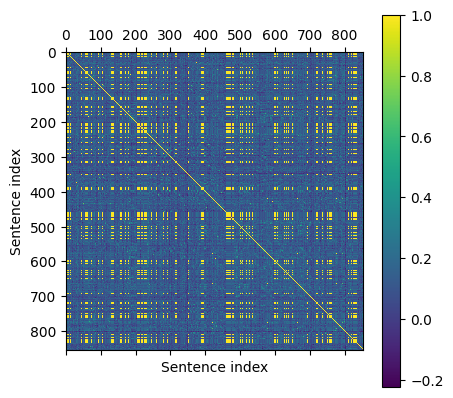

In [ ]:
# similarity matrix, even if hard to read

plt.matshow(similarity_matrix.cpu().numpy())
plt.xlabel('Sentence index')
plt.ylabel('Sentence index')
plt.colorbar()
plt.tight_layout()

<Figure size 1000x800 with 0 Axes>

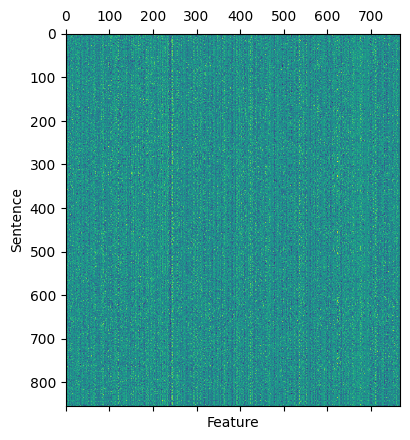

In [ ]:
# embedding space, not very informative

fig = plt.figure(figsize=(10, 8))
plt.matshow(corpus_embeddings.cpu().numpy(), aspect='auto')
plt.xlabel('Feature');
plt.ylabel('Sentence');

## movie semantic coparison

The idea in this sub-chapter is to do a comparison between script with respect to semantic similarity.
For example, can we understand the genre of a movie by semantic similairy score with others known movies?

In [ ]:
movies = dm_lines.script

We use a random generator movie index.
We will compare first movie with the other three.



In [ ]:
import numpy as np

movies_idx = np.random.choice(np.arange(len(movies)), 4)
print(movies_idx)
movie1 = movies[movies_idx[0]]
movieN = [movies[movies_idx[1]], movies[movies_idx[2]], movies[movies_idx[3]]]

print(dm_lines.title[movies_idx[0]])
print(dm_lines.title[movies_idx[1]])
print(dm_lines.title[movies_idx[2]])
print(dm_lines.title[movies_idx[3]])

#101 star trek
#139 the war of the worlds
#425 star war ep-vi
#114 the godfather
#441 saving private ryan

[102 435 270 106]
star trek: the wrath of khan
runaway bride
the fantastic four
star trek vi: the undiscovered country


Here we take away the name of the characters for the movies

In [ ]:
movielines = movie1.split('\n')

processed_lines = []

for line in movielines:
    line = line.strip()

    if ':' in line:
        _, dialogue = line.split(':', 1)

        dialogue = dialogue.strip()

        processed_lines.append(dialogue)
    else:

        processed_lines.append(line)

movie1clean = '\n'.join(processed_lines)


In [ ]:
movielines = []
for mov in movieN:
    lines = mov.split('\n')
    movielines.append(lines)

movieNclean = []

for idx in range(3):

    processed_lines = []

    for line in movielines[idx]:
        line = line.strip()

        if ':' in line:
            _, dialogue = line.split(':', 1)
            dialogue = dialogue.strip()
            processed_lines.append(dialogue)

        else:
            processed_lines.append(line)

    movNclean = '\n'.join(processed_lines)

    movieNclean.append(movNclean)

In [ ]:
mov1_embeddings = model.encode(movie1clean, convert_to_tensor=True, device='cuda')

In [ ]:
indx=0
print(dm_lines.title[movies_idx[indx]])
print(dm_lines.genresIMDB[movies_idx[indx]])
print("\n\n")

for mov in movieNclean:
    indx = indx+1
    movN_embeddings = model.encode(mov, convert_to_tensor=True)
    # Use cosine-similarity and torch.topk to find the highest 5 scores
    cos_scores = util.cos_sim(movN_embeddings,mov1_embeddings)[0]
    # Print the result
    print(cos_scores)
    print(dm_lines.title[movies_idx[indx]])
    print(dm_lines.genresIMDB[movies_idx[indx]])

    print("\n\n")

star trek: the wrath of khan
['action' 'adventure' 'sci-fi' 'thriller']



tensor([0.0978], device='cuda:0')
runaway bride
['comedy' 'romance']



tensor([0.2785], device='cuda:0')
the fantastic four
['action' 'adventure' 'sci-fi' 'fantasy']



tensor([0.4273], device='cuda:0')
star trek vi: the undiscovered country
['action' 'mystery' 'sci-fi' 'thriller']





We noticed that those movie that shared more genres had lighlty or strongly higher score, depend on cases.
In this specific case in fact there is high similarity in the two star trek, almost no similarity to a completely different movie, and quite a medium score on a similar movie

# 4) Genre classifier: vocabulary-based

## Data preprocessing

Here we're grouping the data by movie, creating a long text string for each one, containg all the dialogues in that movie

### Merging procedure

Using the dataset built at point (1)

In [ ]:
movies.head()

,movieID,title,year,ratingIMDB,votes,genresIMDB,movieID_count,script,neg_prob,pos_prob
0,m0,10 things i hate about you,1999,6.9,62847.0,"[comedy, romance]",201,A: Can we make this quick? Roxanne Korrine an...,0.675871,0.324129
1,m1,1492: conquest of paradise,1992,6.2,10421.0,"[adventure, biography, drama, history]",93,A: I never seen heat like this! Not even in L...,0.581932,0.418068
2,m10,affliction,1997,6.9,7252.0,"[drama, mystery, thriller]",115,A: You got yourself a computer Alma.\nB: Been ...,0.777947,0.222053
3,m100,innerspace,1987,6.5,16854.0,"[action, adventure, comedy, crime, sci-fi]",300,A: I said something.\nB: I know you did!\n\nA:...,0.687200,0.312800
4,m101,the insider,1999,8.0,69660.0,"[biography, drama, thriller]",161,A: Hi honey.\nB: Hi Daddy.\nA: What's new?\nB:...,0.695061,0.304939


### Labels

To ease the task we removed from the movies the labels less represented

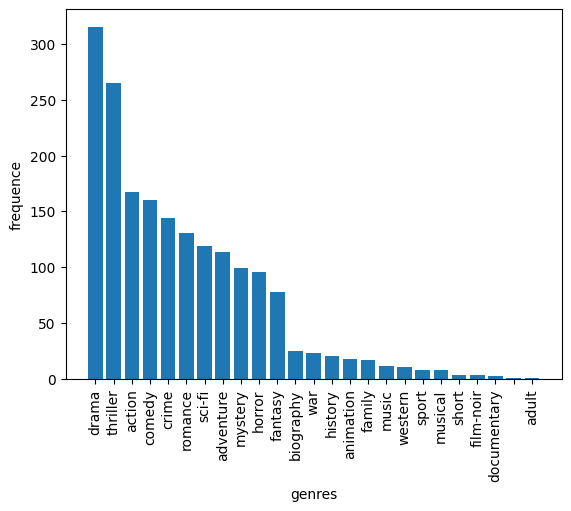

In [ ]:
genres_counter = movies['genresIMDB'].explode().value_counts()

plt.bar(genres_counter.keys(), genres_counter)
plt.xticks(rotation='vertical')

# Adding labels and title
plt.xlabel('genres')
plt.ylabel('frequence')

# Displaying the plot
plt.show()

As we can see the final label distribution is quite unbalnced. It is important to recall this fact while evaluating the results of our model and choose metrics that take into account the unbalance of the data (weighted metrics)

To remove:  ['biography', 'war', 'history', 'animation', 'family', 'music', 'western', 'sport', 'musical', 'short', 'film-noir', 'documentary', '', 'adult']


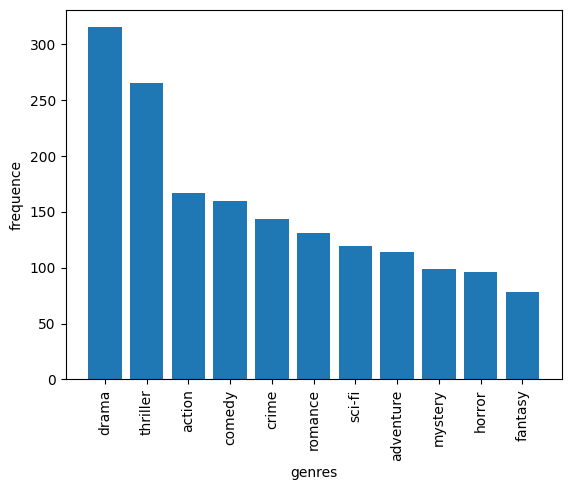

In [ ]:
labels_to_remove = [label for label in genres_counter.keys() if genres_counter[label] < 50]

print("To remove: ", labels_to_remove)
movies['genresIMDB'] = movies.genresIMDB.apply(lambda x: [label for label in x if label not in labels_to_remove])

genres_counter = movies['genresIMDB'].explode().value_counts()

plt.bar(genres_counter.keys(), genres_counter)
plt.xticks(rotation='vertical')

# Adding labels and title
plt.xlabel('genres')
plt.ylabel('frequence')

# Displaying the plot
plt.show()

Here we format the labels to have a binary representation, as requested by the MultiOutputClassifier API by scikit-learn

In [ ]:
genres_binarizer = MultiLabelBinarizer()
binarized_genres = genres_binarizer.fit_transform(movies['genresIMDB'])

# Create a new DataFrame with the binary labels
genres_binarizer.classes_

array(['action', 'adventure', 'comedy', 'crime', 'drama', 'fantasy',
       'horror', 'mystery', 'romance', 'sci-fi', 'thriller'], dtype=object)

### Splitting

In [ ]:
from sklearn.model_selection import train_test_split

movies_train, movies_test, genres_train, genres_test = train_test_split(movies.drop(['genresIMDB'], axis=1),
                                                                        binarized_genres,
                                                                        test_size=1/10, random_state = 42)

movies_train, movies_val, genres_train, genres_val = train_test_split(movies_train,
                                                                      genres_train,
                                                                      test_size=1/9, random_state = 42)

## Model

### Embedding vectorizer

Construction of the embedding vectorizer as seen in Lab5

In [ ]:
import gensim.downloader as api

model_twitter = api.load("glove-twitter-50")

[==================================================] 100.0% 199.5/199.5MB downloaded


In [ ]:
import string

class WordEmbeddingVectorizer(BaseEstimator, TransformerMixin):

  def fit(self, x, y=None):
        return self

  def transform(self, docs, embedding_model=model_twitter, useSum=True):
    regex = '[' + string.punctuation + ']'
    vectors = np.zeros((len(docs),50))
    for i in range(len(docs)):
        tokens = re.sub(regex, '', docs[i].lower()).split()
        embeddings = [embedding_model.get_vector(token) for token in tokens if token in embedding_model]
        if (len(embeddings) > 0):
            if (useSum):
                vectors[i] = sum(embeddings)
            else:
                vectors[i] = np.mean(embeddings, axis=0)
    return vectors

### Estimation infrastructure

This setup allows us to combine the following features
- vectorial representation coming from a text vectorizer, that can be either based on a bag-of-word representation or a embedding representation
- numerical features in the dataset, as rating of the movie
- numerical features crafted by ourselves, like the results from the sentiment analysis performed at point (1)

This setup is a readaption to multilabel classification and embeddings of the code that we found in [this kaggle notebook](https://www.kaggle.com/code/satyabansahoo/gender-classifier)

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class Converter(BaseEstimator, TransformerMixin):
    def fit(self, x, y=None):
        return self

    def transform(self, data_frame):
        return data_frame.values.ravel()

In [ ]:
numeric_features = ['movieID_count', 'ratingIMDB', 'neg_prob','pos_prob']
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('normalize', Normalizer())
])

vectorizer_features = ['script']
vectorizer_transformer = Pipeline(steps=[
    ('con', Converter()),
    ('tf',  TfidfVectorizer())])

In [ ]:
from sklearn.multioutput import MultiOutputClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('vec', vectorizer_transformer, vectorizer_features)
])


xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MultiOutputClassifier(XGBClassifier(objective="binary:logistic")))])

## Training

In [ ]:
xgb.fit(movies_train, genres_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler()),
                                                                  ('normalize',
                                                                   Normalizer())]),
                                                  ['movieID_count',
                                                   'ratingIMDB', 'neg_prob',
                                                   'pos_prob']),
                                                 ('vec',
                                                  Pipeline(steps=[('con',
                                                                   Converter()),
                                                                  ('tf',
                                                                   TfidfVectorizer())]),
                                                  ['script'])])),
                ('classifier',
                 MultiOutputClassifier(estimator=XGBClassifier(base_scor...
                                                               grow_policy=None,
                                                               importance_type=None,
                                                               interaction_constraints=None,
                                                               learning_rate=None,
                                                               max_bin=None,
                                                               max_cat_threshold=None,
                                                               max_cat_to_onehot=None,
                                                               max_delta_step=None,
                                                               max_depth=None,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=None,
                                                               n_jobs=None,
                                                               num_parallel_tree=None,
                                                               random_state=None, ...)))])

## Evaluation

Let's recap quickly the metrics for multilabel classification:

Let $T$ be the set of true labels for a given sample and $P$ the set of the predicted labels for a given sample
- the precision for a given sample is defined as $\frac{|T \cap P|}{|P|}$, i.e. the fraction of the correctly prediceted labels on the total predicted labels
- the recall for a given sample is defined as $\frac{|T \cap P|}{|T|}$, i.e. the fractionof the correctly classified labels over the number of true labels
- as usual F1 is defined as the harmonic mean betwween precision and recall

These metrics can be computed for each labels to have an insight on what our classifier is doing.

In addition to the class-based metrics we can average them for all the labels with various strategy
- the macro average just average the label-based scores
- the weighted average is the weighted version of the macro average
- the micro average shows the average performance across all predictions

The metrics that we're gonna consider are the weighted-averaged f1-score (recalling the class imbalance) and the micro-averaged f1-score

In [ ]:
genres_pred = xgb.predict(movies_test)

print(classification_report(genres_test, genres_pred,
      target_names = genres_binarizer.classes_))

              precision    recall  f1-score   support

      action       0.71      0.33      0.45        15
   adventure       0.33      0.25      0.29         4
      comedy       0.50      0.25      0.33        12
       crime       1.00      0.56      0.71        18
       drama       0.78      0.83      0.81        35
     fantasy       1.00      0.17      0.29         6
      horror       1.00      0.18      0.31        11
     mystery       1.00      0.09      0.17        11
     romance       0.50      0.25      0.33        12
      sci-fi       0.71      0.45      0.56        11
    thriller       0.71      0.56      0.63        27

   micro avg       0.74      0.46      0.57       162
   macro avg       0.75      0.36      0.44       162
weighted avg       0.77      0.46      0.54       162
 samples avg       0.69      0.49      0.54       162



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Results are not incredible, but not that bad either considering the difficulty of the problem. Now let's try to improve by using transformers

# 5) Genre classifier: transformer-based

The issue here was how to group the dialogues by movie. Indeed, previously we were working with long text strings containing all the dialogues in the movie, but doing the same here does not work for two reasons:
- Our dataset does not contain information on the chronological order of the dialogues. The dialogues are actually ordered by the character IDs. Grouping the dialogues would cause a "garbage in, garbage out" problem, as we're creating a chronological order that it's not real. (This we're not a problem with embeddings and tfidf, as that models were not able to learn the context)
- Even if we have a "chronologically" ordered dialogue dataset, the scripts would be very long text strings and the training of a transformer model over such sequences would be unfeasible with our GPU constraints (We could adapt BERT to handle longer sequences, but we would need much more GPU RAM to fit the token sequences in the RAM)

For these reasons we decided to follow this pipeline:
1. train a classifier over a dialogue dataset
2. average the probabilities outputted by the model we have trained to compute a single final prediction for each movie

## Data preprocessing

### Merging procedure

We are gonna format the dialogue using BERT special tokens to help the model during the training

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

Building the dialogues data reusing the conversations_lines data used for the vocabulary-based transformer

**Very important:** In a previuous version of this notebook we formatted the dialogues keeping the names of the characters as speaker identifiers. Using that dialogue format caused the model to learn the association between the names of the characters and the film, and from that the association between names of the characters and genre of the film. So that if in the test set we have dialogues coming from the same movies used in the training, the transformer is able to classify them almost perfectly, but if tested over dialogues coming from unseen movies the results are very poor. This was a reminder for us to be very careful with the data preprocessing steps.

This join utility prevents the problem described before

In [ ]:
def alternate_join(strings):
    result = []
    prefixes = ["A: ", "B: "]
    for i, s in enumerate(strings):
        result.append(prefixes[i % 2] + s)
    return tokenizer.sep_token.join(result)

In [ ]:
# Grouping by index, charID_1, charID_2, and movieID, and aggregating text
dialogues = conversations_lines.groupby(['convID','charID_1','charID_2','movieID']).agg(
    dialogue = ('text', lambda x: alternate_join(x))
).reset_index()

dialogues = dialogues.set_index('convID')

# merge film metadata information
dialogues = pd.merge(
    dialogues, titles,
    on = 'movieID'
)

dialogues['genresIMDB'] = dialogues['genresIMDB'].apply(lambda x: x[2:-2].split("' '"))
dialogues.head()

,charID_1,charID_2,movieID,dialogue,title,year,ratingIMDB,votes,genresIMDB
0,u0,u2,m0,A: Can we make this quick? Roxanne Korrine an...,10 things i hate about you,1999,6.9,62847.0,"[comedy, romance]"
1,u0,u2,m0,A: You're asking me out. That's so cute. What...,10 things i hate about you,1999,6.9,62847.0,"[comedy, romance]"
2,u0,u2,m0,A: No no it's my fault -- we didn't have a pro...,10 things i hate about you,1999,6.9,62847.0,"[comedy, romance]"
3,u0,u2,m0,A: Why?[SEP]B: Unsolved mystery. She used to ...,10 things i hate about you,1999,6.9,62847.0,"[comedy, romance]"
4,u0,u2,m0,A: Gosh if only we could find Kat a boyfriend....,10 things i hate about you,1999,6.9,62847.0,"[comedy, romance]"


### Labels

As before (point (4)), removing labels under a certain amount of occurencies

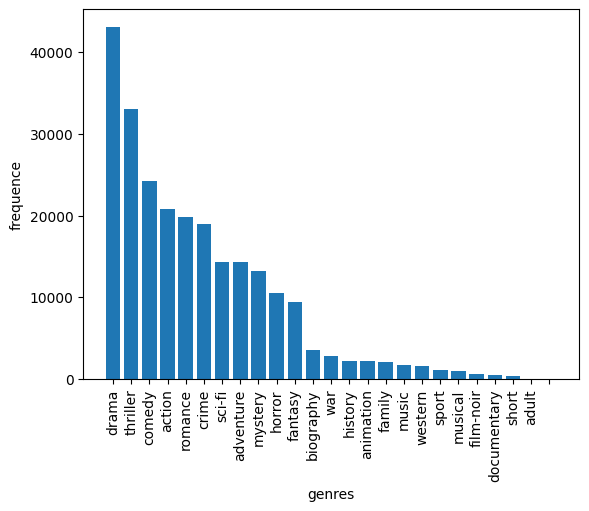

In [ ]:
genres_counter = dialogues['genresIMDB'].explode().value_counts()

plt.bar(genres_counter.keys(), genres_counter)
plt.xticks(rotation='vertical')

# Adding labels and title
plt.xlabel('genres')
plt.ylabel('frequence')

# Displaying the plot
plt.show()

To remove:  ['biography', 'war', 'history', 'animation', 'family', 'music', 'western', 'sport', 'musical', 'film-noir', 'documentary', 'short', 'adult', '']


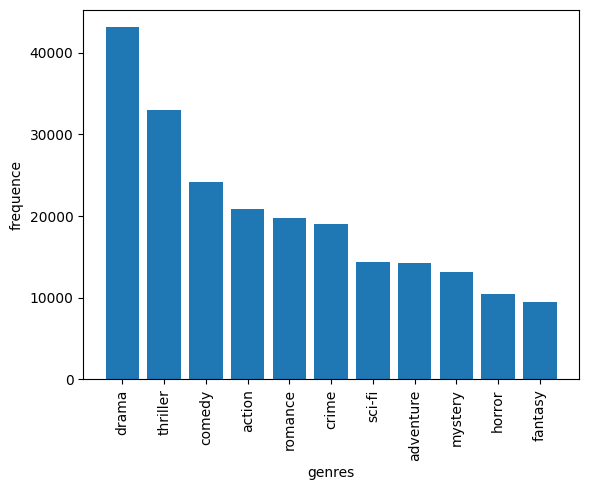

In [ ]:
labels_to_remove = [label for label in genres_counter.keys() if genres_counter[label] < 8000]

print("To remove: ", labels_to_remove)
dialogues['genresIMDB'] = dialogues.genresIMDB.apply(lambda x: [label for label in x if label not in labels_to_remove])

genres_counter = dialogues['genresIMDB'].explode().value_counts()

plt.bar(genres_counter.keys(), genres_counter)
plt.xticks(rotation='vertical')

# Adding labels and title
plt.xlabel('genres')
plt.ylabel('frequence')

# Displaying the plot
plt.show()

Binarize the labels to have them in a compatible format for multilabel classification

In [ ]:
genres_binarizer = MultiLabelBinarizer()

dialogues['binary_genres_repr'] = list(genres_binarizer.fit_transform(dialogues['genresIMDB']))
dialogues['binary_genres_repr'] = [[float(genre_id) for genre_id in sublist] for sublist in dialogues['binary_genres_repr']]

genre_labels = list(genres_binarizer.classes_)
genre_labels

['action',
 'adventure',
 'comedy',
 'crime',
 'drama',
 'fantasy',
 'horror',
 'mystery',
 'romance',
 'sci-fi',
 'thriller']

In [ ]:
id2label = {idx:label for idx, label in enumerate(genre_labels)}
label2id = {label:idx for idx, label in enumerate(genre_labels)}

### Splitting

Once again we have to be careful while splitting the data. Since in the end we want to compute movie-based predictions we split on the movies and not on the dialogues (even if the training is gonna be on the dialogues)

In [ ]:
movieIDs = pd.unique(dialogues.movieID)

test_movieIDs = np.random.choice(movieIDs, size=np.floor(1/10*len(movieIDs)).astype(int),replace=False)
train_movieIDs = movieIDs[~np.isin(movieIDs, test_movieIDs)]

In [ ]:
val_movieIDs = np.random.choice(train_movieIDs, size=np.floor(1/9*len(train_movieIDs)).astype(int),replace=False)
train_movieIDs = movieIDs[~np.isin(movieIDs,np.concatenate((val_movieIDs,test_movieIDs)))]

In [ ]:
print(len(train_movieIDs))
print(len(val_movieIDs))
print(len(test_movieIDs))

486
60
60


In [ ]:
print(len(movieIDs))

606


In [ ]:
#training
dial_train = dialogues[dialogues.movieID.isin(train_movieIDs)][['movieID','dialogue']]
genres_train = dialogues[dialogues.movieID.isin(train_movieIDs)]['binary_genres_repr']

#validation
dial_val = dialogues[dialogues.movieID.isin(val_movieIDs)][['movieID','dialogue']]
genres_val = dialogues[dialogues.movieID.isin(val_movieIDs)]['binary_genres_repr']

#test
dial_test = dialogues[dialogues.movieID.isin(test_movieIDs)][['movieID','dialogue']]
genres_test = dialogues[dialogues.movieID.isin(test_movieIDs)]['binary_genres_repr']

In [ ]:
train_data = [{'text': txt, 'label': lbl} for txt, lbl in zip(dial_train['dialogue'], genres_train)]
val_data = [{'text': txt, 'label': lbl} for txt, lbl in zip(dial_val['dialogue'], genres_val)]
test_data = [{'text': txt, 'label': lbl} for txt, lbl in zip(dial_test['dialogue'], genres_test)]

In [ ]:
data = DatasetDict()
data['train'] = Dataset.from_list(train_data)
data['validation'] = Dataset.from_list(val_data)
data['test'] = Dataset.from_list(test_data)

### Tokenization

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

In [ ]:
def preprocess_data(examples):
  return tokenizer(examples["text"], truncation=True, max_length=256)

tokenized_data = data.map(preprocess_data, batched=True)

Map:   0%|          | 0/63684 [00:00<?, ? examples/s]

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/8361 [00:00<?, ? examples/s]

A very small portion of the data is gonna be truncated. We considered that acceptable

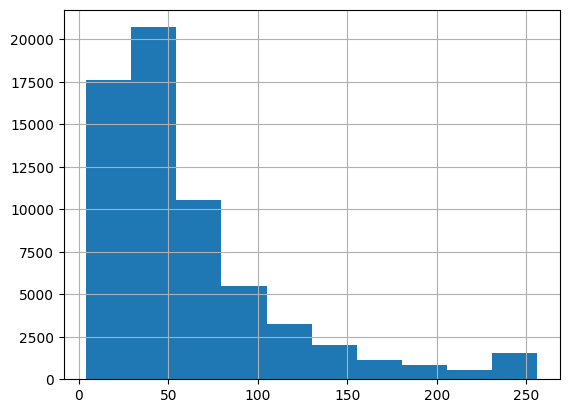

In [ ]:
tokens_len = [len(tokenized_data['train'][i]['input_ids']) for i in range(len(tokenized_data['train']))]

plt.hist(tokens_len)
plt.grid(True)
plt.show()

In [ ]:
tokenized_data.set_format("torch")

## Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("google-bert/bert-base-uncased",
                                                           problem_type="multi_label_classification",
                                                           num_labels=len(genre_labels),
                                                           id2label=id2label,
                                                           label2id=label2id)
model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

## Training

In [ ]:
batch_size = 16

In [ ]:
args = TrainingArguments(
    "bert-training",
    evaluation_strategy = "epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=batch_size,
    auto_find_batch_size=True,
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=4,
    num_train_epochs=2,
    weight_decay=0.01
)

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Specific metrics for multilabel classification: they are described more in datail in the evaluation section at point (4)

In [ ]:
# source: https://jesusleal.io/2021/04/21/Longformer-multilabel-classification/

def multi_label_metrics(predictions, labels, threshold=0.5):
    # first, apply sigmoid on predictions which are of shape (batch_size, num_labels)
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    # next, use threshold to turn them into integer predictions
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    # finally, compute metrics
    y_true = labels
    f1_weighted_average = f1_score(y_true=y_true, y_pred=y_pred, average='weighted')
    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro')

    # return as dictionary
    metrics = {'f1_micro': f1_micro_average, 'f1_weighted': f1_weighted_average}
    return metrics

def compute_metrics(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions,
            tuple) else p.predictions
    result = multi_label_metrics(
        predictions=preds,
        labels=p.label_ids)
    return result

Actual training

In [ ]:
trainer = Trainer(
    model,
    args,
    train_dataset=tokenized_data["train"],
    eval_dataset=tokenized_data["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

/opt/conda/lib/python3.10/site-packages/accelerate/accelerator.py:446: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


In [ ]:
trainer.train()

/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Weighted
0,No log,0.464036,0.411496,0.383659
1,0.467900,0.486160,0.430098,0.411669


/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


TrainOutput(global_step=994, training_loss=0.43117302140479596, metrics={'train_runtime': 2767.9254, 'train_samples_per_second': 46.016, 'train_steps_per_second': 0.359, 'total_flos': 1.4358454188508344e+16, 'train_loss': 0.43117302140479596, 'epoch': 2.0})

### Tuning the threshold parameter

To get a final prediction we tune the threshold parameter on the validation set

In [ ]:
val_pred = trainer.predict(tokenized_data['validation'])

/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


Computing the probabilities outputted by BERT on the validation set. Recall that the validation set is a set of dialogues, so the predictions have to be averaged by movies.

In [ ]:
def multi_label_probs(predictions):
    # first, apply sigmoid on predictions which are of shape (batch_size, num_labels)
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))

    return probs

def compute_probs(p: EvalPrediction):
    preds = p.predictions[0] if isinstance(p.predictions,
            tuple) else p.predictions
    result = multi_label_probs(
        predictions=preds)
    return result

In [ ]:
dial_val['probs'] = list(compute_probs(val_pred).numpy())
dial_val['labels'] = [np.array(lab) for lab in genres_val]

Grouping the prediction by movie

In [ ]:
val_mov_pred = dial_val.groupby(['movieID']).agg(
    probs = ('probs', lambda x : np.mean(x, axis=0)),
    labels = ('labels', lambda x: np.mean(x, axis=0))
)

Tuning the k parameter to maximize the macro f1-score since we give to each class equal importance

In [ ]:
f1_scores = np.zeros(101)
grid_k = np.linspace(0,1,101)

for i in range(len(grid_k)):
    f1_scores[i] = f1_score(y_true=list(val_mov_pred['labels']),
                            y_pred=list(val_mov_pred['probs'].apply(lambda x:  (x > grid_k[i]).astype(int))),
                            average='macro')

selected_k = grid_k[np.argmax(f1_scores)]

In [ ]:
selected_k

0.24

## Evaluation

Finally let's evaluate our classifier on the test set

In [ ]:
genres_pred = trainer.predict(tokenized_data['test'])

/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


As before,
- computing probabilities

In [ ]:
dial_test['probs'] = list(compute_probs(genres_pred).numpy())
dial_test['labels'] = [np.array(lab) for lab in genres_test]

- average by movie

In [ ]:
mov_pred = dial_test.groupby(['movieID']).agg(
    probs = ('probs', lambda x : np.mean(x, axis=0)),
    labels = ('labels', lambda x: np.mean(x, axis=0))
)

Here we have the evaluation of the classifier over the test set. We got an improvement with respect to the classifier based on vocabulary

In [ ]:
print(classification_report(list(mov_pred['labels']), list(mov_pred['probs'].apply(lambda x:  (x > selected_k).astype(int))),
      target_names = genres_binarizer.classes_))

              precision    recall  f1-score   support

      action       0.64      0.82      0.72        17
   adventure       0.62      0.73      0.67        11
      comedy       0.49      1.00      0.65        17
       crime       0.59      0.87      0.70        15
       drama       0.57      1.00      0.73        33
     fantasy       0.67      0.22      0.33         9
      horror       0.60      0.50      0.55         6
     mystery       0.50      0.15      0.24        13
     romance       0.40      0.71      0.51        14
      sci-fi       0.80      0.62      0.70        13
    thriller       0.47      1.00      0.64        27

   micro avg       0.54      0.78      0.64       175
   macro avg       0.58      0.69      0.58       175
weighted avg       0.56      0.78      0.62       175
 samples avg       0.55      0.82      0.64       175



In conclusion, results are not that incredible, we assume that having movie scripts could improve a lot the performances of a transformer-based classifier. However, the pipeline we developed to handle this task still achieve an imporvement in the performances w.r.t the previous model.

Still this classifier has many issues in handling the unbalnced class, an imporvement could be achieved by using advanced stratified sampling algorithms for multilabel classification.

# 6) Dialogue generation

In this section we followed two approaches:
- in the first one we formatted the dialogues as seen in class, adding a little description of the two characters in the scene. However, it was unfeasible to get a description for each pair of characters and so we tried to fine-tune on just a couple of characters
- in the second one, removing character descriptions and with some work-arounds to make the training feasible, we fine-tuned a small gpt2 over the whole dialogues corpus

## Fine-tuning over dialogues between specific characters

### Selection of characters

In [ ]:
dataset_path = "cornell movie-dialogs corpus"

In [ ]:
conversationsO = pd.read_csv(
    f"{dataset_path}/movie_conversations.tsv",
    sep='\t',
    encoding='ISO-8859-2',
    names = ['charID_1', 'charID_2', 'movieID', 'conversation']
)
conversationsO.dropna(inplace=True)

In [ ]:
conversationsO['conversation'] = conversationsO['conversation'].map(lambda x: re.findall(r"\w+", x))
conversationsO['length'] = conversationsO['conversation'].apply(lambda x: len(x))
conversationsO.sort_values(by=['length'], ascending=False)

,charID_1,charID_2,movieID,conversation,length
42477,u4522,u4525,m299,"[L135360, L135361, L135362, L135363, L135364, ...",89
73134,u7932,u7936,m537,"[L553902, L553903, L553904, L553905, L553906, ...",59
70355,u7663,u7666,m518,"[L513247, L513248, L513249, L513250, L513251, ...",56
45571,u4857,u4866,m324,"[L167261, L167262, L167263, L167264, L167265, ...",55
11348,u1240,u1243,m82,"[L267558, L267559, L267560, L267561, L267562, ...",54
...,...,...,...,...,...
20661,u2256,u2265,m145,"[L412100, L412101]",2
55457,u6020,u6022,m400,"[L308227, L308228]",2
11491,u1244,u1248,m82,"[L268306, L268307]",2
55459,u6021,u6024,m400,"[L308517, L308518]",2


look for the couple that interact the most in a random movie

In [ ]:
def find_most_frequent_interaction_for_movie(characters, lines, movies, conversations, movie_title):
    interactions_count = {}

    # Find the movie ID given the title
    movie_id = movies[movies['title'] == movie_title].index[0]

    movie_lines = lines[lines['movieID'] == movie_id]


    movie_conversations = conversations[conversations['movieID'] == movie_id]


    for _, conversation in movie_conversations.iterrows():
        char_id_1 = conversation['charID_1']
        char_id_2 = conversation['charID_2']


        char_name_1 = characters.loc[char_id_1].charName
        char_name_2 = characters.loc[char_id_2].charName


        interaction_key = tuple(sorted([char_name_1, char_name_2]))


        interactions_count[interaction_key] = interactions_count.get(interaction_key, 0) + 1

    # Find the pair of characters with the highest number of interactions
    most_frequent_interaction = max(interactions_count, key=interactions_count.get)

    return most_frequent_interaction, interactions_count[most_frequent_interaction]

In [ ]:
movie_title = "10 things i hate about you"
most_frequent_interaction, num_interactions = find_most_frequent_interaction_for_movie(characters, lines, titles, conversationsO, movie_title)

char1, char2 = most_frequent_interaction
print(f"The pair of characters with the most interactions in '{movie_title}' is:")
print(f"{char1} and {char2}")
print(f"Number of interactions: {num_interactions}")

The pair of characters with the most interactions in '10 things i hate about you' is:
KAT and PATRICK
Number of interactions: 40


### Dialogue extraction

firstly extract a list containing the conversations among the two characters

In [ ]:
def extract_dialogues_between_characters_list(movie_title, character_name_1, character_name_2, characters, movies, lines, conversations):
    # Get the movie ID
    movie_id = movies[movies['title'] == movie_title].index[0]

    # Get the character IDs
    char_id_1 = characters[characters['charName'] == character_name_1].index[0]
    char_id_2 = characters[characters['charName'] == character_name_2].index[0]
    # Get all conversations for this movie and involving the specified characters
    relevant_convos = conversations[(conversations['movieID'] == movie_id) &
                                    (((conversations['charID_1'] == char_id_1) & (conversations['charID_2'] == char_id_2)) |
                                     ((conversations['charID_1'] == char_id_2) & (conversations['charID_2'] == char_id_1)))]

    dialogues_between_characters = []

    for i, conversation in relevant_convos.iterrows():
        convo_text = []

        for lineID in conversation.conversation:
            try:
                line = lines.loc[lineID]
                convo_text.append(f"{line.charName} : {line.text}")  # Add each line to the convo_text list
            except KeyError:
                continue

        dialogue_string = ' '.join(convo_text)
        dialogues_between_characters.append(dialogue_string)

    return dialogues_between_characters

In [ ]:
data_kat_patrick=extract_dialogues_between_characters_list('10 things i hate about you', 'KAT','PATRICK', characters, titles, lines, conversationsO)
data_kat_patrick[0]

"PATRICK : I mean Wo-man.  How ya doin'? KAT : Sweating like a pig actually.  And yourself? PATRICK : There's a way to get a guy's attention. KAT : My mission in life."

Now I extract the same dialogues as one long string, for further usage

In [ ]:
def extract_dialogues_between_characters(movie_title, character_name_1, character_name_2, characters, movies, lines, conversations):
    # Get the movie ID
    movie_id = movies[movies['title'] == movie_title].index[0]

    # Get the character IDs
    char_id_1 = characters[characters['charName'] == character_name_1].index[0]
    char_id_2 = characters[characters['charName'] == character_name_2].index[0]


    relevant_convos = conversations[(conversations['movieID'] == movie_id) &
                                    (((conversations['charID_1'] == char_id_1) & (conversations['charID_2'] == char_id_2)) |
                                      ((conversations['charID_1'] == char_id_2) & (conversations['charID_2'] == char_id_1)))]

    dialogue_between_characters = []


    for i, conversation in relevant_convos.iterrows():
        convo_text = []

        for lineID in conversation.conversation:
            try:
                line = lines.loc[lineID]
                convo_text.append(f"{line.charName} : {line.text}")
            except KeyError:
                continue


        dialogue_between_characters.append(' '.join(convo_text))

    return dialogue_between_characters


In [ ]:
data_Kat_Patrick_tot=extract_dialogues_between_characters('10 things i hate about you', 'KAT','PATRICK', characters, titles, lines, conversationsO)
data_Kat_Patrick_tot[:10]

["PATRICK : I mean Wo-man.  How ya doin'? KAT : Sweating like a pig actually.  And yourself? PATRICK : There's a way to get a guy's attention. KAT : My mission in life.",
 'PATRICK : Pick you up Friday then KAT : Oh right.  Friday.',
 "PATRICK : The night I take you to places you've never been before.  And back. KAT : Like where?  The 7-Eleven on Burnside? Do you even know my name screwboy? PATRICK : I know a lot more than that",
 "PATRICK : You hate me don't you? KAT : I don't really think you warrant that strong an emotion. PATRICK : Then say you'll spend Dollar Night at the track with me. KAT : And why would I do that? PATRICK : Come on -- the ponies the flat beer you with money in your eyes me with my hand on your ass... KAT : You -- covered in my vomit. PATRICK : Seven-thirty?",
 "KAT : Are you following me? PATRICK : I was in the laundromat. I saw your car. Thought I'd say hi. KAT : Hi",
 "PATRICK : You're not a big talker are you? KAT : Depends on the topic. My fenders don't rea

In [ ]:
def create_dialogue(dialogue_list):
    # Inizializza la lista degli utterances
    utterances = []

    # Itera attraverso i dialoghi
    for dialogue in dialogue_list:
        # Dividi il dialogo in speaker e testo
        speaker, text = dialogue.split(' : ', 1)

        # Aggiungi il dialogo agli utterances
        utterances.append({'speaker': speaker.strip(), 'text': text.strip()})

    return utterances

In [ ]:
utterances = create_dialogue(data_Kat_Patrick_tot)

### Load train data

In [ ]:
kat = [ "I'm Kat, a determined and rebellious girl. I don't care about following society's rules.",
       "I enjoy reading classic books and discussing social issues. I can't stand hypocrisy and injustice.",
       "I'm straightforward and honest in my opinions. Some call me a feminist, but I prefer to think of myself as someone with a strong sense of justice.",
       "I have a passion for poetry and writing. I love expressing myself through words and ideas.",
       "I'm protective of my younger sister Bianca, even though I don't always show it openly."
]


In [ ]:
patrick = [ "My name's Patrick, and I'm the kind of guy who marches to the beat of his own drum. I don't like following the crowd.",
           "I have a sharp sense of humor and a laid-back attitude. I don't take myself too seriously.",
            "I'm a bit mysterious and have my own past. Some think I'm just a troublemaker, but there's more to me than meets the eye.",
            "I enjoy alternative music and playing guitar. I find freedom in art and creativity.",
            "I don't like being labeled or judged. I'm more complicated than I seem, but I prefer people to figure that out for themselves."

]


now we try to replicate the fuction parse_pc(path) of lab_09, but taking strings as input instead of a file.txt

In [ ]:
def convert_dialogue_string_to_utterances(dialogue_string):

    utterances = []


    dialogue_lines = re.split(r'(KAT|PATRICK) :', dialogue_string)


    dialogue_lines = [line.strip() for line in dialogue_lines if line.strip()]


    current_speaker = None
    for i in range(len(dialogue_lines)):
        if dialogue_lines[i] in ["KAT", "PATRICK"]:

            current_speaker = 'A' if dialogue_lines[i] == "KAT" else 'B'
        else:

            utterances.append({'speaker': current_speaker, 'text': dialogue_lines[i].strip()})

    return utterances

create structure for utterances

In [ ]:
def create_dialogue_structure(persona_a, persona_b, utterances):
    # create structure for the dialogue
    dialogue_structure = {
        'persona_a': persona_a,
        'persona_b': persona_b,
        'utterances': utterances
    }

    return dialogue_structure

In [ ]:
def parse_pc(persona_a, persona_b, utterances):
    # Create the dialogue structure list
    dialogue_structure = []

    for utterance in utterances:
        ut=convert_dialogue_string_to_utterances(utterance)
        element = create_dialogue_structure(persona_a, persona_b, ut)
        if element:
            dialogue_structure.append(element)

    return dialogue_structure

In [ ]:
struttura_train_list=parse_pc(kat, patrick,data_kat_patrick)

Now we are going to convert to strings all the samples using the eos_token as separator.






In [ ]:
def sample_to_string(sample, eos_token):
    # Join strings of Persona A
    persona_a = ' '.join(sample['persona_a'])
    # Join strings of Persona B
    persona_b = ' '.join(sample['persona_b'])
    # Join dialogue strings
    dialogue = eos_token.join(f"{utterance['speaker']}: {utterance['text']}" for utterance in sample['utterances'])
    # Build the dialogue string
    dialogue_string = f"Persona A: {persona_a}{eos_token}Persona B: {persona_b}{eos_token}{dialogue}{eos_token}"

    return dialogue_string

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type != 'cuda':
    raise SystemError('GPU device not found')

model_id = 'gpt2-medium'

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)
model.to(device)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

In [ ]:
tokenizer.pad_token = tokenizer.eos_token

Apply the funtion to all samples

since dataset is quite small, we decided to use it all for train_data

In [ ]:
training_data_str = [sample_to_string(dialogue, tokenizer.eos_token) for dialogue in struttura_train_list]

now samples are ready

In [ ]:
from datasets import Dataset

train_data = Dataset.from_dict({'text': training_data_str})

In [ ]:
from datasets import DatasetDict

data = DatasetDict()
data['train'] = train_data

use the tokenizer to convert the input strings into sequences of tokens.

In [ ]:
!pip -q install --upgrade ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.4/139.4 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 56.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.2 MB/s eta 0:00:00


In [ ]:
def tokenize_function(examples):
    input_encodings = tokenizer(examples["text"], padding=False, truncation=True)
    sample = {
        'input_ids': input_encodings.input_ids
    }
    return sample

tokenized_data = data.map(tokenize_function, batched=True)

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

In [ ]:
!pip install transformers[torch]

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    "cooler_trainer_name",
    evaluation_strategy="steps",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,  # Gradient accumulation to use batch sized larger the available VRAM
    learning_rate=6.25e-5,
    lr_scheduler_type="linear",
    #bf16=True  # Mixed precision training, to speed up and save memory
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
from transformers import TrainingArguments, Trainer

trainer = Trainer(
    model=AutoModelForCausalLM.from_pretrained('gpt2'),
    args=training_args,
    train_dataset=tokenized_data['train'],
    #eval_dataset=tokenized_data['validation'],
    data_collator=data_collator)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

### Training

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss


TrainOutput(global_step=3, training_loss=2.7709337870279946, metrics={'train_runtime': 11.4881, 'train_samples_per_second': 10.446, 'train_steps_per_second': 0.261, 'total_flos': 16067418624000.0, 'train_loss': 2.7709337870279946, 'epoch': 2.4})

In [ ]:
from datetime import datetime

checkpoint_path = f"persona_chat_fine_tuning_{datetime.now().strftime('%Y_%m_%d_%H_%M_%S')}"
tokenizer.save_pretrained(checkpoint_path)
model.save_pretrained(checkpoint_path)
print(f"Checkpoint saved at: \'{checkpoint_path}\'")

Checkpoint saved at: 'persona_chat_fine_tuning_2024_05_25_13_15_45'


starting to generate right in the middle of their interactions

In [ ]:
response_idx = 20
original_response = utterances[response_idx]
original_response_string = f"{original_response['speaker']}: {original_response['text']}"
original_response_string

"PATRICK: So what ' s up with your dad?  He a pain in the ass? KAT : He just wants me to be someone I'm not. PATRICK : Who? KAT : BIANCA PATRICK : No offense but you're sister is without.  I know everyone likes her and all but ..."

In [ ]:
context = {
    'persona_a': kat,
    'persona_b': patrick,
    'utterances': utterances[:response_idx]
}
context_string = sample_to_string(context, tokenizer.eos_token)
print(context_string.replace(tokenizer.eos_token, '\n'))

Persona A: I'm Kat, a determined and rebellious girl. I don't care about following society's rules. I enjoy reading classic books and discussing social issues. I can't stand hypocrisy and injustice. I'm straightforward and honest in my opinions. Some call me a feminist, but I prefer to think of myself as someone with a strong sense of justice. I have a passion for poetry and writing. I love expressing myself through words and ideas. I'm protective of my younger sister Bianca, even though I don't always show it openly.
Persona B: My name's Patrick, and I'm the kind of guy who marches to the beat of his own drum. I don't like following the crowd. I have a sharp sense of humor and a laid-back attitude. I don't take myself too seriously. I'm a bit mysterious and have my own past. Some think I'm just a troublemaker, but there's more to me than meets the eye. I enjoy alternative music and playing guitar. I find freedom in art and creativity. I don't like being labeled or judged. I'm more com

In [ ]:
# checkpoint_path = 'persona_chat_fine_tuning_2024_05_08_11_49_58'
tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)
model = AutoModelForCausalLM.from_pretrained(checkpoint_path)

model.to(device)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

In [ ]:
# Encode context
input_encoding = tokenizer(context_string, return_tensors='pt', truncation=True, max_length=512).to(device)
# Generate response
output_ids = model.generate(input_encoding.input_ids, max_new_tokens=64, do_sample=True, temperature=0.7, top_p=0.85, top_k=25,  pad_token_id=tokenizer.eos_token_id)
# Decode generated response
generated_response = tokenizer.decode(output_ids[0, input_encoding.input_ids.size(1):], skip_special_tokens=True)
generated_response


" That's weird. PATRICK : You know I don't know you, but you're really cute. KAT : I know. PATRICK : It's like you've been in my life. KAT : That's right. PATRICK : You know I don't know you, but you're"

### Evaluation

final result of the prediction:

In [ ]:
decoded_text = tokenizer.decode(input_encoding['input_ids'][0], skip_special_tokens=True)

# find specific index
start_index = decoded_text.find("KAT: Are you following me?")

specific_text = decoded_text[start_index:]
print(specific_text[:103])
print("\n")
print(generated_response)



KAT: Are you following me? PATRICK : I was in the laundromat. I saw your car. Thought I'd say hi. KAT :


 That's weird. PATRICK : You know I don't know you, but you're really cute. KAT : I know. PATRICK : It's like you've been in my life. KAT : That's right. PATRICK : You know I don't know you, but you're


## Fine-tuning over the whole dataset

### Data preprocessing

Here we build astructured dialogue dataset

In [ ]:
conversations_lines['lines_dict'] = conversations_lines[['charName','text']].apply(lambda x: {'speaker': x['charName'], 'text': x['text']}, axis=1)

In [ ]:
conversations_lines.head()

,convID,charID_1,charID_2,movieID,lineID,charID,charName,text,lines_dict
0,0,u0,u2,m0,L194,u0,BIANCA,Can we make this quick? Roxanne Korrine and A...,"{'speaker': 'BIANCA', 'text': 'Can we make thi..."
1,0,u0,u2,m0,L195,u2,CAMERON,Well I thought we'd start with pronunciation i...,"{'speaker': 'CAMERON', 'text': 'Well I thought..."
2,0,u0,u2,m0,L196,u0,BIANCA,Not the hacking and gagging and spitting part....,"{'speaker': 'BIANCA', 'text': 'Not the hacking..."
3,0,u0,u2,m0,L197,u2,CAMERON,Okay... then how 'bout we try out some French ...,"{'speaker': 'CAMERON', 'text': 'Okay... then h..."
4,1,u0,u2,m0,L198,u0,BIANCA,You're asking me out. That's so cute. What's ...,"{'speaker': 'BIANCA', 'text': 'You're asking m..."


In [ ]:
# Grouping by index, charID_1, charID_2, and movieID, and aggregating text
dialogues = conversations_lines.groupby(['convID','charID_1','charID_2','movieID']).agg(
    characters = ('charName', lambda x: pd.unique(x)),
    utterances = ('lines_dict', lambda x: list(x))).reset_index()

dialogues = dialogues.set_index('convID')

# merge film metadata information
dialogues = pd.merge(
    dialogues, titles,
    on = 'movieID'
)

dialogues.drop(columns=['charID_1', 'charID_2'], inplace=True)
dialogues.head()

,movieID,characters,utterances,title,year,ratingIMDB,votes,genresIMDB
0,m0,"[BIANCA, CAMERON]","[{'speaker': 'BIANCA', 'text': 'Can we make th...",10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']
1,m0,"[BIANCA, CAMERON]","[{'speaker': 'BIANCA', 'text': 'You're asking ...",10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']
2,m0,"[BIANCA, CAMERON]","[{'speaker': 'BIANCA', 'text': 'No no it's my ...",10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']
3,m0,"[CAMERON, BIANCA]","[{'speaker': 'CAMERON', 'text': 'Why?'}, {'spe...",10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']
4,m0,"[BIANCA, CAMERON]","[{'speaker': 'BIANCA', 'text': 'Gosh if only w...",10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']


Final dialogue structure

In [ ]:
dialogues['utterances'][0]

[{'speaker': 'BIANCA',
  'text': 'Can we make this quick?  Roxanne Korrine and Andrew Barrett are having an incredibly horrendous public break- up on the quad.  Again.'},
 {'speaker': 'CAMERON',
  'text': "Well I thought we'd start with pronunciation if that's okay with you."},
 {'speaker': 'BIANCA',
  'text': 'Not the hacking and gagging and spitting part.  Please.'},
 {'speaker': 'CAMERON',
  'text': "Okay... then how 'bout we try out some French cuisine.  Saturday?  Night?"}]

In [ ]:
dialogues = dialogues[dialogues.characters.apply(lambda x: len(x)>=1)]

In [ ]:
dialogues[['charName_1','charName_2']] = pd.DataFrame(dialogues['characters'].tolist(),
                                                      index=dialogues.index)
dialogues.drop(columns=['characters'], inplace=True)
dialogues.head()

,movieID,utterances,title,year,ratingIMDB,votes,genresIMDB,charName_1,charName_2
0,m0,"[{'speaker': 'BIANCA', 'text': 'Can we make th...",10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance'],BIANCA,CAMERON
1,m0,"[{'speaker': 'BIANCA', 'text': 'You're asking ...",10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance'],BIANCA,CAMERON
2,m0,"[{'speaker': 'BIANCA', 'text': 'No no it's my ...",10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance'],BIANCA,CAMERON
3,m0,"[{'speaker': 'CAMERON', 'text': 'Why?'}, {'spe...",10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance'],CAMERON,BIANCA
4,m0,"[{'speaker': 'BIANCA', 'text': 'Gosh if only w...",10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance'],BIANCA,CAMERON


This converts the structured dialogues to the final

In [ ]:
def sample_to_string(sample, eos_token):
    # Join dialogue strings
    dialogue = eos_token.join(f"{utterance['speaker']}: {utterance['text']}" for utterance in sample['utterances'])
    # Build the dialogue string
    dialogue_string = f"The characters in this scene are {sample['charName_1']} and {sample['charName_2']} from the movie {sample['title']}{eos_token}{dialogue}{eos_token}"

    return dialogue_string

In [ ]:
from sklearn.model_selection import train_test_split

dial_train, dial_val = train_test_split(dialogues[['charName_1','charName_2','title','utterances']],
                                         test_size=0.20,
                                         random_state = 42)

In [ ]:
from datasets import Dataset, DatasetDict

data = DatasetDict()
data['train'] = Dataset.from_dict({'context': list(dial_train.apply(lambda x: sample_to_string(x, eos_token), axis=1))})
data['validation'] = Dataset.from_dict({'context': list(dial_val.apply(lambda x: sample_to_string(x, eos_token), axis=1))})

### Model

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_id = 'gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_id)

eos_token = tokenizer.eos_token

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type != 'cuda':
    raise SystemError('GPU device not found')

model = AutoModelForCausalLM.from_pretrained(model_id)
model.to(device)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
tokenizer.pad_token = tokenizer.eos_token

def tokenize_function(examples):
    input_encodings = tokenizer(examples["context"], padding=False, truncation=True, max_length=256)
    sample = {
        'input_ids': input_encodings.input_ids
    }
    return sample

tokenized_data = data.map(tokenize_function, batched=True)
tokenized_data.set_format("torch")

Map:   0%|          | 0/63832 [00:00<?, ? examples/s]

Map:   0%|          | 0/15959 [00:00<?, ? examples/s]

### Training

In [ ]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    "cooler_trainer_name",
    evaluation_strategy="steps",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,  # Gradient accumulation to use batch sized larger the available VRAM
    learning_rate=6.25e-5,
    num_train_epochs=1,
    lr_scheduler_type="linear",
    #bf16=True  # Mixed precision training, to speed up and save memory
)

In [ ]:
from transformers import TrainingArguments, Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_data['train'],
    eval_dataset=tokenized_data['validation'],
    data_collator=data_collator)

/opt/conda/lib/python3.10/site-packages/accelerate/accelerator.py:446: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(


Training over the large training dialogue corpus

In [ ]:
trainer.train()

/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


Step,Training Loss,Validation Loss
500,2.576800,2.395581


/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '


TrainOutput(global_step=997, training_loss=2.5014415806011785, metrics={'train_runtime': 2679.2249, 'train_samples_per_second': 23.825, 'train_steps_per_second': 0.372, 'total_flos': 5644597865472000.0, 'train_loss': 2.5014415806011785, 'epoch': 1.0})

### Evaluation

Testing on the validation set

In [ ]:
tokenized_data['validation']['context'][100]

"The characters in this scene are LEIA and CHEWIE from the movie star wars: the empire strikes back<|endoftext|>LEIA: Okay Chewie it's now or never.<|endoftext|>CHEWIE: Barks his agreement.<|endoftext|>"

In [ ]:
# Encode context
input_encoding = tokenizer(tokenized_data['validation']['context'][300], return_tensors='pt', truncation=True, max_length=256).to(device)
# Generate response
output_ids = model.generate(input_encoding.input_ids, max_new_tokens=32, do_sample=True, temperature=0.9, top_p=0.9, top_k=0, pad_token_id=tokenizer.eos_token_id)
# Decode generated response
generated_response = tokenizer.decode(output_ids[0, input_encoding.input_ids.size(1):], skip_special_tokens=False)
generated_response

A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


"LEIA: Is everything done?  We're no longer back in the Jedi land.  The Empire has lost control over them.  The Jedi have no"

The text generation seems pretty good. For instance here the model is able to understand that we're talking about jedi even if they are not directly cited in the input sequence

# 7) Techniques application

Here we create a bot with a specific task:

  1. bot: explaining the task

  2. user: says the name of a movie

  3. semantic comparison on the titles

  4. bot: say which are the two main characters that the user will describe later on

  5. display of the most significant phrases, based on sentiments

  6. user: says 3 phrases each to describe the two characters

  7. generation of the dialogue

We use different techniques from all over the project

## Enviroment

In [ ]:
!pip install transformers
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 18.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 23.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 17.0 MB/s eta 0:00:00


In [ ]:
# speech to text
!pip install ffmpeg-python # metto come primo per oscuro mistero
!pip install -U openai-whisper # metto come primo per oscuro mistero

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.6/798.6 kB 13.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.2 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using c

In [ ]:
# semantica
!pip install -U sentence-transformers
!pip install datasets
!pip install hnswlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.5/171.5 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hnswlib: filename=hnswlib-0.8.0-cp310-cp310-linux_x86_64.whl size=2319657 sha256=ecaf63c322ad7951b73ce6708f1442144bda0d65ee07bb689804d0896c4b714c
  Stored in directory: /root/.cache/pip/wheels/af/a9/3e/3e5d59ee41664eb31a4e6de67d1846f86d16d93c45f277c4e7
Successfully built hnswlib


In [ ]:
# dialogo
!pip install torch torchvision torchaudio
!pip install accelerate
!pip -q install --upgrade ipywidgets
!pip install transformers[torch] accelerate -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.4/139.4 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 44.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 16.3 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.41.0
    Uninstalling transformers-4.41.0:
      Successfully uninstalled transformers-4.41.0


In [ ]:
dataset_path = "cornell movie-dialogs corpus"

In [ ]:
# tutti import
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
import seaborn as sns
import os

# pt1
import torch
from IPython.display import Audio

# pt2
from IPython.display import HTML, Audio
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
from scipy.io.wavfile import read as wav_read
import io
import ffmpeg
import scipy
import whisper

# pt3
from sentence_transformers import SentenceTransformer, util
import pandas as pd

# pt5
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F
import numpy as np

## pt7
from transformers import AutoModelForCausalLM
from transformers import DataCollatorForLanguageModeling
from transformers import TrainingArguments
from transformers import Trainer
from datetime import datetime
from datasets import Dataset
from datasets import DatasetDict

In [ ]:
conversations = pd.read_csv(
    f"{dataset_path}/movie_conversations.tsv",
    sep='\t',
    encoding='ISO-8859-2',
    names = ['charID_1', 'charID_2', 'movieID', 'conversation']
)
conversations['conversation'] = conversations['conversation'].apply(lambda x: x[2:-2].split("' '"))
conversations.dropna(inplace=True)


characters = pd.read_csv(
    f"{dataset_path}/movie_characters_metadata.tsv",
    sep='\t',
    header = None,
    on_bad_lines= "skip",
    names = ['charID','charName','movieID','movieName','gender','score'],
    index_col=['charID']
)
characters.dropna(inplace=True)

lines = pd.read_csv(
    f"{dataset_path}/movie_lines.tsv",
    encoding='utf-8-sig',
    sep='\t',
    on_bad_lines="skip",
    header = None,
    names = ['lineID', 'charID', 'movieID', 'charName', 'text'],
    index_col=['lineID']
)
lines.dropna(inplace=True)

titles = pd.read_csv(
    f"{dataset_path}/movie_titles_metadata.tsv",
    sep='\t',
    header=None,
    on_bad_lines="skip",
    names=['movieID', 'title', 'year', 'ratingIMDB', 'votes', 'genresIMDB'],
    index_col=['movieID']
)
titles.dropna(inplace=True)

In [ ]:
!pip install numpy scipy librosa unidecode inflect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 4.3 MB/s eta 0:00:00


## Base functions and models

### 1. Bot speaking

In [ ]:
tacotron2 = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_tacotron2', model_math='fp16')
tacotron2 = tacotron2.to('cuda')
tacotron2.eval()

/usr/local/lib/python3.10/dist-packages/torch/hub.py:293: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/NVIDIA/DeepLearningExamples/zipball/torchhub" to /root/.cache/torch/hub/torchhub.zip
/root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn

Tacotron2(
  (embedding): Embedding(148, 512)
  (encoder): Encoder(
    (convolutions): ModuleList(
      (0-2): 3 x Sequential(
        (0): ConvNorm(
          (conv): Conv1d(512, 512, kernel_size=(5,), stride=(1,), padding=(2,))
        )
        (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (lstm): LSTM(512, 256, batch_first=True, bidirectional=True)
  )
  (decoder): Decoder(
    (prenet): Prenet(
      (layers): ModuleList(
        (0): LinearNorm(
          (linear_layer): Linear(in_features=80, out_features=256, bias=False)
        )
        (1): LinearNorm(
          (linear_layer): Linear(in_features=256, out_features=256, bias=False)
        )
      )
    )
    (attention_rnn): LSTMCell(768, 1024)
    (attention_layer): Attention(
      (query_layer): LinearNorm(
        (linear_layer): Linear(in_features=1024, out_features=128, bias=False)
      )
      (memory_layer): LinearNorm(
        (linear_layer): Linear(in_fea

In [ ]:
waveglow = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_waveglow', model_math='fp16')
waveglow = waveglow.remove_weightnorm(waveglow)
waveglow = waveglow.to('cuda')
waveglow.eval()

Using cache found in /root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub
/usr/local/lib/python3.10/dist-packages/torch/nn/utils/weight_norm.py:28: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


WaveGlow(
  (upsample): ConvTranspose1d(80, 80, kernel_size=(1024,), stride=(256,))
  (WN): ModuleList(
    (0-3): 4 x WN(
      (in_layers): ModuleList(
        (0): Conv1d(512, 1024, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): Conv1d(512, 1024, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
        (2): Conv1d(512, 1024, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
        (3): Conv1d(512, 1024, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
        (4): Conv1d(512, 1024, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
        (5): Conv1d(512, 1024, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
        (6): Conv1d(512, 1024, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
        (7): Conv1d(512, 1024, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      )
      (res_skip_layers): ModuleList(
        (0-6): 7 x Conv1d(512, 1024, kernel_size=(1,), stride=(1,))
        (7

In [ ]:
bot1 = "Hi,choose a movie from the catalogue, otherwise I will solve the task with the movie in our database which has the most similar title."
bot2 = "The task is that I will take the two of the main characters of the movie and, after a short desciption given by you, I will create new dialogs from them"

In [ ]:
utils = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_tts_utils')
sequences1, lengths1 = utils.prepare_input_sequence([bot1])
sequences2, lengths2 = utils.prepare_input_sequence([bot2])

with torch.no_grad():
    mel1, _, _ = tacotron2.infer(sequences1, lengths1)
    mel2, _, _ = tacotron2.infer(sequences2, lengths2)

with torch.no_grad():
    audio1 = waveglow.infer(mel1)
    audio2 = waveglow.infer(mel2)
audio_numpy1 = audio1[0].data.cpu().numpy()
audio_numpy2 = audio2[0].data.cpu().numpy()

rate = 22050

Using cache found in /root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub
/root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/SpeechSynthesis/Tacotron2/tacotron2/text/__init__.py:74: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  return s in _symbol_to_id and s is not '_' and s is not '~'
/root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/SpeechSynthesis/Tacotron2/tacotron2/text/__init__.py:74: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  return s in _symbol_to_id and s is not '_' and s is not '~'


### 2. User speaking

In [ ]:
AUDIO_HTML = """
<script>
var my_div = document.createElement("DIV");
var my_p = document.createElement("P");
var my_btn = document.createElement("BUTTON");
var t = document.createTextNode("Press to start recording");

my_btn.appendChild(t);
//my_p.appendChild(my_btn);
my_div.appendChild(my_btn);
document.body.appendChild(my_div);

var base64data = 0;
var reader;
var recorder, gumStream;
var recordButton = my_btn;

var handleSuccess = function(stream) {
  gumStream = stream;
  var options = {
    //bitsPerSecond: 8000, //chrome seems to ignore, always 48k
    mimeType : 'audio/webm;codecs=opus'
    //mimeType : 'audio/webm;codecs=pcm'
  };
  //recorder = new MediaRecorder(stream, options);
  recorder = new MediaRecorder(stream);
  recorder.ondataavailable = function(e) {
    var url = URL.createObjectURL(e.data);
    var preview = document.createElement('audio');
    preview.controls = true;
    preview.src = url;
    document.body.appendChild(preview);

    reader = new FileReader();
    reader.readAsDataURL(e.data);
    reader.onloadend = function() {
      base64data = reader.result;
      //console.log("Inside FileReader:" + base64data);
    }
  };
  recorder.start();
  };

recordButton.innerText = "Recording... press to stop";

navigator.mediaDevices.getUserMedia({audio: true}).then(handleSuccess);


function toggleRecording() {
  if (recorder && recorder.state == "recording") {
      recorder.stop();
      gumStream.getAudioTracks()[0].stop();
      recordButton.innerText = "Saving the recording... pls wait!"
  }
}

// https://stackoverflow.com/a/951057
function sleep(ms) {
  return new Promise(resolve => setTimeout(resolve, ms));
}

var data = new Promise(resolve=>{
//recordButton.addEventListener("click", toggleRecording);
recordButton.onclick = ()=>{
toggleRecording()

sleep(2000).then(() => {
  // wait 2000ms for the data to be available...
  // ideally this should use something like await...
  //console.log("Inside data:" + base64data)
  resolve(base64data.toString())

});

}
});

</script>
"""

def get_audio():
  display(HTML(AUDIO_HTML))
  data = eval_js("data")
  binary = b64decode(data.split(',')[1])

  process = (ffmpeg
    .input('pipe:0')
    .output('pipe:1', format='wav')
    .run_async(pipe_stdin=True, pipe_stdout=True, pipe_stderr=True, quiet=True, overwrite_output=True)
  )
  output, err = process.communicate(input=binary)

  riff_chunk_size = len(output) - 8
  # Break up the chunk size into four bytes, held in b.
  q = riff_chunk_size
  b = []
  for i in range(4):
      q, r = divmod(q, 256)
      b.append(r)

  # Replace bytes 4:8 in proc.stdout with the actual size of the RIFF chunk.
  riff = output[:4] + bytes(b) + output[8:]

  sr, audio = wav_read(io.BytesIO(riff))

  return audio, sr

In [ ]:
modelWhisper = whisper.load_model("base")

100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 137MiB/s]


### 3. Semantic on titles

In [ ]:
titles_df = pd.DataFrame.from_dict(titles)
movie_titles = titles_df['title'].tolist()
clean_movie_titles = [str(title) for title in movie_titles if isinstance(title, str)]

In [ ]:
cosmodel = SentenceTransformer('all-mpnet-base-v2')

docs_embeddings = cosmodel.encode(clean_movie_titles, convert_to_tensor=True, device='cuda')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# also with crossEncoder
### from sentence_transformers import CrossEncoder
### model = CrossEncoder('cross-encoder/stsb-distilroberta-base')
### model_inputs = [[query, doc] for doc in clean_movie_titles]
### # Predict similarity score
### scores = model.predict(model_inputs)
### # top n
### top_5_indices = np.argsort(-scores)[:5]
### # Print the result
### print(f"Query: \"{query}\"")
### print("---------------------------------------")
### for idx in top_5_indices:
###     print(f"Score: {scores[idx]:.4f} - Document: \"{clean_movie_titles[idx]}\"")
### print("\n\n\n\n")

### 4. Bot speaking again

In [ ]:
conversationsO = pd.read_csv(
    f"{dataset_path}/movie_conversations.tsv",
    sep='\t',
    encoding='ISO-8859-2',
    names = ['charID_1', 'charID_2', 'movieID', 'conversation']
)
conversationsO.dropna(inplace=True)

In [ ]:
conversationsO['conversation'] = conversationsO['conversation'].map(lambda x: re.findall(r"\w+", x))
conversationsO['length'] = conversationsO['conversation'].apply(lambda x: len(x))
conversationsO.sort_values(by=['length'], ascending=False)

,charID_1,charID_2,movieID,conversation,length
42477,u4522,u4525,m299,"[L135360, L135361, L135362, L135363, L135364, ...",89
73134,u7932,u7936,m537,"[L553902, L553903, L553904, L553905, L553906, ...",59
70355,u7663,u7666,m518,"[L513247, L513248, L513249, L513250, L513251, ...",56
45571,u4857,u4866,m324,"[L167261, L167262, L167263, L167264, L167265, ...",55
11348,u1240,u1243,m82,"[L267558, L267559, L267560, L267561, L267562, ...",54
...,...,...,...,...,...
20661,u2256,u2265,m145,"[L412100, L412101]",2
55457,u6020,u6022,m400,"[L308227, L308228]",2
11491,u1244,u1248,m82,"[L268306, L268307]",2
55459,u6021,u6024,m400,"[L308517, L308518]",2


In [ ]:
def find_most_frequent_interaction_for_movie(characters, lines, movies, conversations, movie_title):
    interactions_count = {}  # Dizionario per conteggiare le interazioni

    # Trova l'ID del film dato il titolo
    movie_id = movies[movies['title'] == movie_title].index[0]

    # Filtra le linee di dialogo per il film specifico
    movie_lines = lines[lines['movieID'] == movie_id]

    # Filtra le conversazioni per il film specifico
    movie_conversations = conversations[conversations['movieID'] == movie_id]

    # Ciclo attraverso tutte le conversazioni del film specifico
    for _, conversation in movie_conversations.iterrows():
        char_id_1 = conversation['charID_1']
        char_id_2 = conversation['charID_2']

        # Trova i nomi dei personaggi corrispondenti agli ID
        char_name_1 = characters.loc[char_id_1].charName
        char_name_2 = characters.loc[char_id_2].charName

        # Creazione di una chiave univoca per la coppia di personaggi
        interaction_key = tuple(sorted([char_name_1, char_name_2]))

        # Aggiornamento del conteggio delle interazioni per questa coppia di personaggi
        interactions_count[interaction_key] = interactions_count.get(interaction_key, 0) + 1

    # Trova la coppia di personaggi con il maggior numero di interazioni
    most_frequent_interaction = max(interactions_count, key=interactions_count.get)

    return most_frequent_interaction, interactions_count[most_frequent_interaction]

### 5. Significant dialogues

In [ ]:
def extract_dialogues_between_characters(movie_title, character_name_1, character_name_2, characters, movies, lines, conversations):
    # Get the movie ID
    movie_id = movies[movies['title'] == movie_title].index[0]

    # Get the character IDs
    char_id_1 = characters[characters['charName'] == character_name_1].index[0]
    char_id_2 = characters[characters['charName'] == character_name_2].index[0]

    # Get all conversations for this movie and involving the specified characters
    relevant_convos = conversations[(conversations['movieID'] == movie_id) &
                                    (((conversations['charID_1'] == char_id_1) & (conversations['charID_2'] == char_id_2)) |
                                     ((conversations['charID_1'] == char_id_2) & (conversations['charID_2'] == char_id_1)))]

    dialogue_between_characters = []

    # Loop through the relevant conversations
    for i, conversation in relevant_convos.iterrows():
        convo_text = []  # Create an empty list to store the lines of this conversation

        for lineID in conversation.conversation:
            try:
                line = lines.loc[lineID]
                convo_text.append(f"{line.charName} : {line.text}")  # Add each line to the convo_text list
            except KeyError:
                continue

        # Join the conversation lines together into a single string and add to the dialogue_between_characters list
        dialogue_between_characters.append(' '.join(convo_text))

    return dialogue_between_characters

In [ ]:
deviceD = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

tokenizerD = AutoTokenizer.from_pretrained("Positroniy/bertweet-base-sentiment-analysis-trained_on_3000")
modelD = AutoModelForSequenceClassification.from_pretrained("Positroniy/bertweet-base-sentiment-analysis-trained_on_3000")
modelD.to(deviceD)

tokenizer_config.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


config.json:   0%|          | 0.00/847 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(64001, 768, padding_idx=1)
      (position_embeddings): Embedding(130, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
label_names = ["negative", "positive"]

def predict(text):
    input_encodings = tokenizerD(text, return_tensors='pt', padding=True, truncation=True).to(device)
    outputs = modelD(**input_encodings)
    logits = outputs.logits

    probabilities = F.softmax(logits, dim=-1)
    predicted_probabilities = probabilities.detach().cpu().numpy()

    lbl = label_names[np.argmax(predicted_probabilities)]

    return lbl, predicted_probabilities, np.max(predicted_probabilities)

### 6. Characters Description

all in bot

### 7. Dialogue between bots

In [ ]:
def create_dialogue_structure(persona_a, persona_b, utterances):
    # create structure for the dialogue
    dialogue_structure = {
        'persona_a': persona_a,
        'persona_b': persona_b,
        'utterances': utterances
    }

    return dialogue_structure

def create_dialogue(dialogue_list):
    # Initialize the list of utterances
    utterances = []

    # Iterate through the dialogues
    for dialogue in dialogue_list:
        # Split the dialogue into speaker and text
        speaker, text = dialogue.split(' : ', 1)

        # Add the dialogue to the utterances
        utterances.append({'speaker': speaker.strip(), 'text': text.strip()})

    return utterances

# Converting to strings all the samples using the eos_token as separator.

def sample_to_string(sample, eos_token):
    # Join strings of Persona A
    persona_a = ' '.join(sample['persona_a'])
    # Join strings of Persona B
    persona_b = ' '.join(sample['persona_b'])
    # Join dialogue strings
    dialogue = eos_token.join(f"{utterance['speaker']}: {utterance['text']}" for utterance in sample['utterances'])
    # Build the dialogue string
    dialogue_string = f"Persona A: {persona_a}{eos_token}Persona B: {persona_b}{eos_token}{dialogue}{eos_token}"

    return dialogue_string

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type != 'cuda':
    raise SystemError('GPU device not found')

model_id = 'gpt2-medium'

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)
model.to(device)

tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
def tokenize_function(examples):
    input_encodings = tokenizer(examples["text"], padding=True, truncation=True)
    sample = {
        'input_ids': input_encodings.input_ids
    }
    return sample

In [ ]:
data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

In [ ]:
training_args = TrainingArguments(
    "cooler_trainer_name",
    evaluation_strategy="steps",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,  # Gradient accumulation to use batch sized larger the available VRAM
    learning_rate=6.25e-5,
    lr_scheduler_type="linear",
    #bf16=True  # Mixed precision training, to speed up and save memory
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
checkpoint_path = f"persona_chat_fine_tuning_{datetime.now().strftime('%Y_%m_%d_%H_%M_%S')}"
tokenizer.save_pretrained(checkpoint_path)
model.save_pretrained(checkpoint_path)
print(f"Checkpoint saved at: \'{checkpoint_path}\'")

Checkpoint saved at: 'persona_chat_fine_tuning_2024_05_24_11_06_04'


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(checkpoint_path)
model = AutoModelForCausalLM.from_pretrained(checkpoint_path)

model.to(device)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1024)
    (wpe): Embedding(1024, 1024)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-23): 24 x GPT2Block(
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1024, out_features=50257, bias=False)
)

## Final Bot

### Functions

Creo funzioni di tutto ciò che mi serve

In [ ]:
def userVoice1(audio, sr):

    scipy.io.wavfile.write('movie_name.wav', sr, audio)
    result = modelWhisper.transcribe("movie_name.wav")
    chosenMovie = result["text"]

    return chosenMovie

def semanticMovie(query):

    top_k = min(1, len(clean_movie_titles))
    query_embedding = cosmodel.encode(query, convert_to_tensor=True)
    # Use cosine-similarity and torch.topk to find the highest 5 scores
    cos_scores = util.cos_sim(query_embedding, docs_embeddings)[0]
    top_results = torch.topk(cos_scores, k=top_k)
    # Print the result
    print(f"Query: \"{query}\"")
    print("Top 5 most similar sentences in corpus:")
    print("---------------------------------------")
    for score, idx in zip(top_results[0], top_results[1]):
        print(f"Score: {score:.2f} - Document: \"{clean_movie_titles[idx]}\"")
        return clean_movie_titles[idx]


def botCh(ch1, ch2):

    botch = "the two carachters are:"
    full_text = f"{botch} {ch1} and {ch2}"

    sequences, lengths = utils.prepare_input_sequence([full_text])
    with torch.no_grad():
        mel, _, _ = tacotron2.infer(sequences, lengths)

    with torch.no_grad():
        audio = waveglow.infer(mel)
    audio_numpy = audio[0].data.cpu().numpy()
    rate = 22050
    audio_numpy

    display(Audio(audio_numpy, rate=rate))

    return full_text

def create_dialogue_structure(persona_a, persona_b, utterances):
    # create structure for the dialogue
    dialogue_structure = {
        'persona_a': persona_a,
        'persona_b': persona_b,
        'utterances': utterances
    }

    return dialogue_structure

def create_dialogue(dialogue_list):
    # Initialize the list of utterances
    utterances = []

    # Iterate through the dialogues
    for dialogue in dialogue_list:
        # Split the dialogue into speaker and text
        speaker, text = dialogue.split(' : ', 1)

        # Add the dialogue to the utterances
        utterances.append({'speaker': speaker.strip(), 'text': text.strip()})

    return utterances

# Converting to strings all the samples using the eos_token as separator.

def sample_to_string(sample, eos_token):
    # Join strings of Persona A
    persona_a = ' '.join(sample['persona_a'])
    # Join strings of Persona B
    persona_b = ' '.join(sample['persona_b'])
    # Join dialogue strings
    dialogue = eos_token.join(f"{utterance['speaker']}: {utterance['text']}" for utterance in sample['utterances'])
    # Build the dialogue string
    dialogue_string = f"Persona A: {persona_a}{eos_token}Persona B: {persona_b}{eos_token}{dialogue}{eos_token}"

    return dialogue_string

### Bot

In [ ]:
response_idx = 20

print('Hi,choose a movie from the catalogue, otherwise I will solve the task with the movie in our database which has the most similar title.')
display(Audio(audio_numpy1, rate=rate))

print('The task is that I will take the two of the main characters of the movie and, after a short desciption given by you, I will create new dialogs from them')
display(Audio(audio_numpy2, rate=rate))

print('say the name of the movie')
audio, sr = get_audio()

movie = userVoice1(audio, sr)

real_movie = semanticMovie(movie)

most_frequent_interaction, num_interactions = find_most_frequent_interaction_for_movie(characters, lines, titles, conversationsO, real_movie)
char1, char2 = most_frequent_interaction

bot_text_ch = botCh(char1,char2)
print(bot_text_ch)

full_data = extract_dialogues_between_characters(real_movie, char1, char2, characters, titles, lines, conversationsO)

results = []

for phrase in full_data:
    predicted_label, predicted_probabilities, max_probability = predict(phrase)
    results.append((phrase, predicted_label, max_probability))

# Sort the results by the maximum probability in descending order
sorted_results = sorted(results, key=lambda x: x[2], reverse=True)

# Get the top n most significant phrases
top_10_significant_phrases = sorted_results[:10]
#print(top_10_significant_phrases)
df = pd.DataFrame(top_10_significant_phrases, columns=['Phrase', 'Sentiment', 'Score'])
pd.set_option('display.max_colwidth', None)
print(df[['Phrase']])


print(f"dici 3 frasi per descrivere {char1}")
list1 = []
list2 = []

for ii in range(3):
    print(f"{char1}, phrase {ii+1}:")
    audio, sr = get_audio()
    scipy.io.wavfile.write('phraseC.wav', sr, audio)
    result = modelWhisper.transcribe("phraseC.wav")
    list1.append(result["text"])

print(f"dici 3 frasi per descrivere {char2}")

for jj in range(3):
    print(f"{char2}, phrase {jj+1}:")
    audio, sr = get_audio()
    scipy.io.wavfile.write('phraseC.wav', sr, audio)
    result = modelWhisper.transcribe("phraseC.wav")
    list2.append(result["text"])



utterances = create_dialogue(full_data)
struttura_train=create_dialogue_structure(char1,char2,utterances)
training_data=[struttura_train]

training_data_str = [sample_to_string(dialogue, tokenizer.eos_token) for dialogue in training_data]

train_data = Dataset.from_dict({'text': training_data_str})
data = DatasetDict()
data['train'] = train_data

tokenized_data = data.map(tokenize_function, batched=True)


trainer = Trainer(
    model=AutoModelForCausalLM.from_pretrained('gpt2-medium'),
    args=training_args,
    train_dataset=tokenized_data['train'],
    #eval_dataset=tokenized_data['validation'],
    data_collator=data_collator)

trainer.train()

context = {
    'persona_a': char1,
    'persona_b': char2,
    'utterances': utterances[:response_idx]
}
context_string = sample_to_string(context, tokenizer.eos_token)

# Encode context
input_encoding = tokenizer(context_string, return_tensors='pt', truncation=True, max_length=512).to(device)
# Generate response
output_ids = model.generate(input_encoding.input_ids, max_new_tokens=128, do_sample=True, temperature=0.7, top_p=0.85, top_k=50,  pad_token_id=tokenizer.eos_token_id)
# Decode generated response
generated_response = tokenizer.decode(output_ids[0, input_encoding.input_ids.size(1):], skip_special_tokens=True)

generated_response

Hi,choose a movie from the catalogue, otherwise I will solve the task with the movie in our database which has the most similar title.


The task is that I will take the two of the main characters of the movie and, after a short desciption given by you, I will create new dialogs from them


say the name of the movie


Query: " Eternal sunshine of a spotless mind."
Top 5 most similar sentences in corpus:
---------------------------------------
Score: 0.98 - Document: "eternal sunshine of the spotless mind"


the two carachters are: CLEMENTINE and JOEL
                                                                                                                                                                                                                                                                                                                Phrase
0                                                                                                                                                                                              CLEMENTINE : How can you watch this crap? JOEL : Where are you going? CLEMENTINE : I'm fucking crawling out of my skin.
1                                                                         JOEL : I can't believe you wrecked my car. You're driving drunk. It's pathetic. CLEMENTINE : ...a little. I was a little tipsy. Don't call me pathetic. JOEL : Well it is pathetic. And fucking irresponsible. You could've killed somebody.
2                      

...

JOEL, phrase 2:


JOEL, phrase 3:


Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss


" CLEMENTINE : I was going to tell you it was just me but then I noticed that it was really nice. JOEL : That's nice. I don't know why I didn't notice it sooner. CLEMENTINE : Because you look like you're wearing a dress. JOEL : You're wearing a dress? CLEMENTINE : Yeah. JOEL : Well I've seen you in dresses before. CLEMENTINE : And I'm not wearing a dress. JOEL : No. CLEMENTINE : So it's not like you're not wearing a dress. JOEL : No. CLEMENTINE : It's"